Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

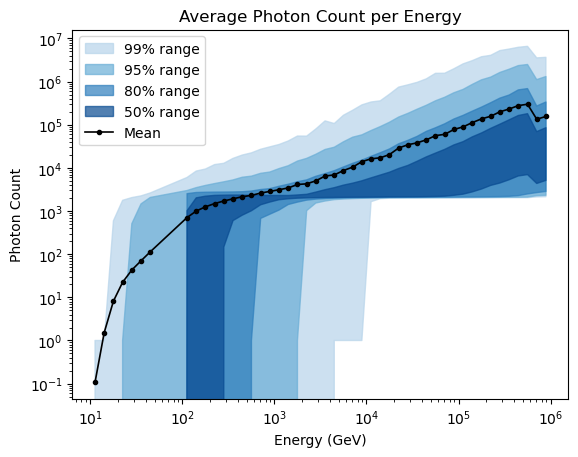

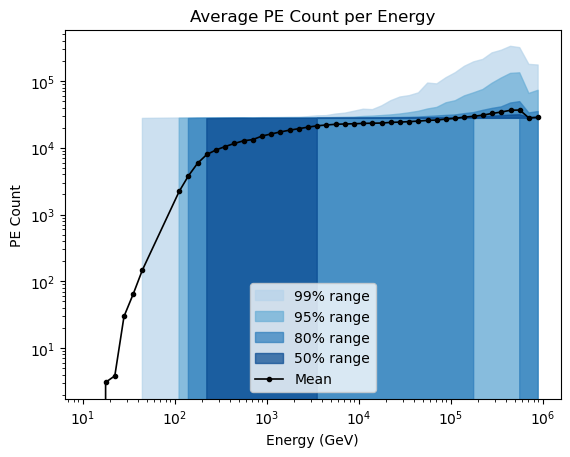

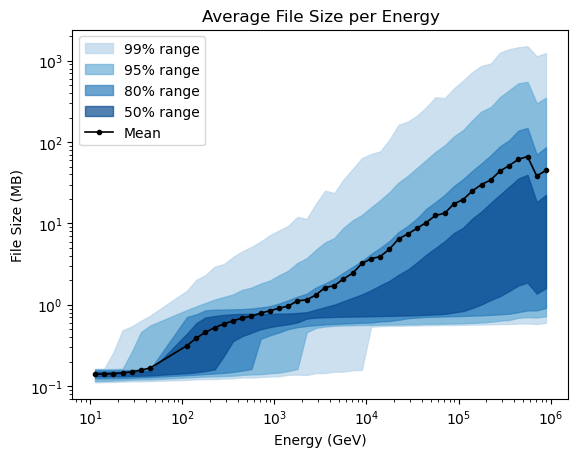

8.134073722987003 TB 4304.751132174003 photon per MB


In [1]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
#N_BOOTSTRAP = 1000
#CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    arg = (obs_height / zem) * np.sin(theta)
    arg = np.clip(arg, -1.0, 1.0)
    beta = np.where(np.isfinite(arg), np.arcsin(arg), 0.0)
    beta = np.clip(beta, 0.0, np.pi/2)
    #beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence


import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"])
X = np.array(df["tel_x"])
Z = np.array(df["tel_z"])
H = np.array(df["height"])
Zenith = np.array(df["zen"])
Azimuth = np.array(df["az"])
Max_PE = np.array(df["max_pe"])
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"])
Avg_PE = np.array(df["avg_pe"])
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"])
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth)
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
#x_mag = np.array(df["correction_x_m"])
#y_mag = np.array(df["correction_y_m"])
file_size = np.array(df["file_size_MB"])
photon_count = np.array(df["cph_photon_count"])
#max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))
deleted_low_pe = np.array(df["deleted_low_pe"])

File = []
Photon = []
PE = []

File_low, File_high = [], []
Photon_low, Photon_high = [], []
PE_low, PE_high = [], []

Total_FIle_Size = np.nansum(file_size)/1000 - np.nansum(file_size[deleted_low_pe==1])/1000#MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 99]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}

for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Total_PE[mask])
    File.append(f)
    Photon.append(p)
    PE.append(pe)

    # 99% range (legacy)
    File_low.append(np.nanpercentile(file_size[mask], 0.5))
    File_high.append(np.nanpercentile(file_size[mask], 99.5))
    Photon_low.append(np.nanpercentile(photon_count[mask], 0.5))
    Photon_high.append(np.nanpercentile(photon_count[mask], 99.5))
    PE_low.append(np.nanpercentile(Total_PE[mask], 0.5))
    PE_high.append(np.nanpercentile(Total_PE[mask], 99.5))

    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Total_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Total_PE[mask], hi_p))

File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)

File_low, File_high     = np.array(File_low),   np.array(File_high)
Photon_low, Photon_high = np.array(Photon_low), np.array(Photon_high)
PE_low, PE_high         = np.array(PE_low),     np.array(PE_high)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))


def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count per Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "PE Count", "Average PE Count per Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size per Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


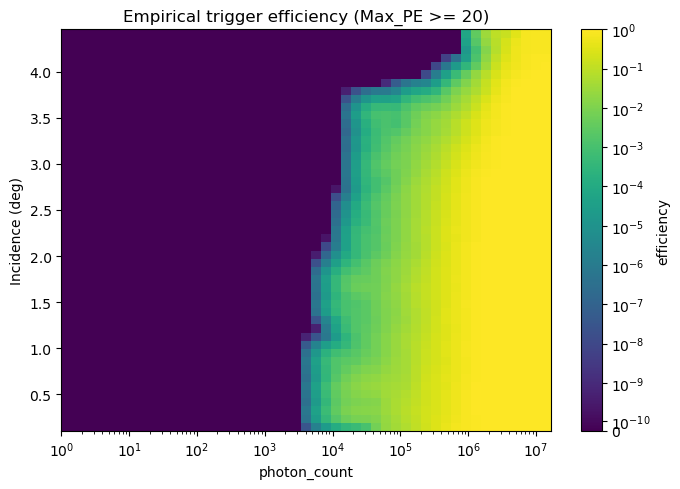

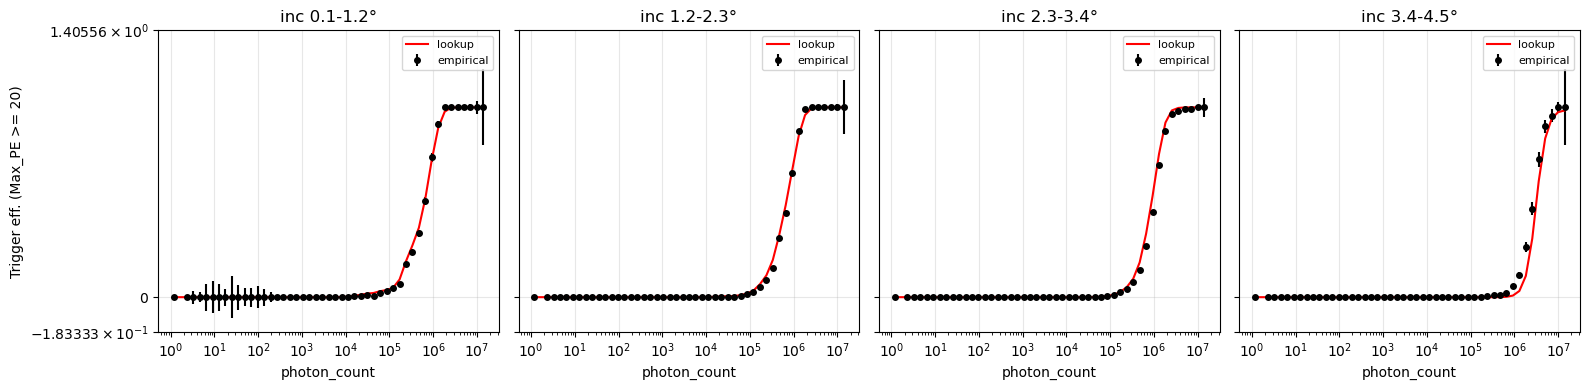

In [2]:
# Empirical trigger efficiency: P(Max_PE >= threshold | photon_count, incidence)
# =============================================================================
from scipy.ndimage import gaussian_filter
from matplotlib.colors import SymLogNorm

# ---------- 1. Clean inputs ----------
m = (np.isfinite(photon_count) & (photon_count > 0)
     & np.isfinite(Max_PE)     & (Max_PE >= 0)
     & np.isfinite(Incidence))
pc_  = photon_count[m]
pe_  = Max_PE[m]
inc_ = Incidence[m]
hit_ = (pe_ >= PE_THRESHOLD).astype(float)

# ---------- 2. Define 2-D bins ----------
pc_edges  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 50)
inc_edges = np.linspace(inc_.min(),inc_.max(), 50)
pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5*(inc_edges[:-1] + inc_edges[1:])

# ---------- 3. Build empirical efficiency table ----------
N_tot, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges])
N_hit, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges], weights=hit_)

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(N_tot >= 5, N_hit / N_tot, np.nan)
    eff_err = np.where(N_tot >= 5, np.sqrt(eff*(1-eff)/N_tot), np.nan)

# Light smoothing to fill noisy bins (optional)
eff_smooth = eff.copy()
mask = np.isfinite(eff_smooth)
eff_smooth[~mask] = 0
weights = mask.astype(float)
eff_smooth = gaussian_filter(eff_smooth, sigma=0.8) / np.clip(
    gaussian_filter(weights, sigma=0.8), 1e-6, None)

# ---------- 4. Lookup function with bilinear interpolation ----------
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (np.log10(pc_cen), inc_cen), eff_smooth,
    bounds_error=False, fill_value=None, method='linear')

def trigger_eff(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])
    vals = np.clip(interp(pts), 0.0, 1.0)
    return vals.reshape(N_b.shape)

# ---------- 5. Plot the efficiency map ----------
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(pc_edges, inc_edges, eff_smooth.T,
                    cmap='viridis', shading='auto', norm=SymLogNorm(linthresh=np.min(eff_smooth[np.where(eff_smooth>0)]), linscale=0.5, base=10))
ax.set_xscale('log')
ax.set_xlabel("photon_count"); ax.set_ylabel("Incidence (deg)")
ax.set_title(f"Empirical trigger efficiency (Max_PE >= {PE_THRESHOLD})")
plt.colorbar(pcm, ax=ax, label='efficiency')
plt.tight_layout(); plt.show()

# ---------- 6. Slice validation ----------
bounds = np.linspace(inc_.min(), inc_.max(), 5)
slices = list(zip(bounds[:-1], bounds[1:]))
fig, axes = plt.subplots(1, len(slices), figsize=(4*len(slices), 4), sharey=True)
for ax, (ilo, ihi) in zip(axes, slices):
    sel = (inc_ >= ilo) & (inc_ < ihi)
    emp, err = [], []
    for i in range(len(pc_cen)):
        s2 = sel & (pc_ >= pc_edges[i]) & (pc_ < pc_edges[i+1])
        n = s2.sum()
        if n >= 5:
            p = np.mean(hit_[s2]); emp.append(p)
            err.append(np.sqrt(p*(1-p)/n) + 1.0/n)
        else:
            emp.append(np.nan); err.append(np.nan)
    emp, err = np.array(emp), np.array(err)
    pred = trigger_eff(pc_cen, 0.5*(ilo+ihi))
    ax.errorbar(pc_cen, emp, yerr=err, fmt='ko', ms=4, label='empirical')
    ax.plot(pc_cen, pred, 'r-', label='lookup')
    ax.set_xscale('log')#; ax.set_ylim(-0.05, 1.1)
    ax.set_yscale('symlog')
    ax.set_xlabel("photon_count")
    ax.set_title(f"inc {ilo:.1f}-{ihi:.1f}°")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
plt.tight_layout(); plt.show()


PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS
Fit equation: eff(x) = b / (1 + exp((x - x0) / w))
Error bars:   bootstrap 68% CI (N_boot=100)
--------------------------------------------------------------------------------
     pc_mean          b         ±b         x0        ±x0          w         ±w   chi2/dof     minN
--------------------------------------------------------------------------------
   1.585e+04    0.00443     0.0075      1.698      0.081      0.001       0.03       0.01    15680
   1.995e+04    0.00482     0.0062      1.788        0.2      0.030        0.2       0.02    11181
   2.512e+04    0.00525     0.0064      1.885       0.34      0.043       0.29       0.01    13045
   3.162e+04    0.00693     0.0072      1.760      0.051      0.001      0.025       0.02    10924
   3.981e+04    0.00392     0.0054      2.120       0.34      0.050       0.33       0.08     8136
   5.012e+04      0.007     0.0037      1.969      0.003      0.001     0.0077       0.10     9677
   6.310e+

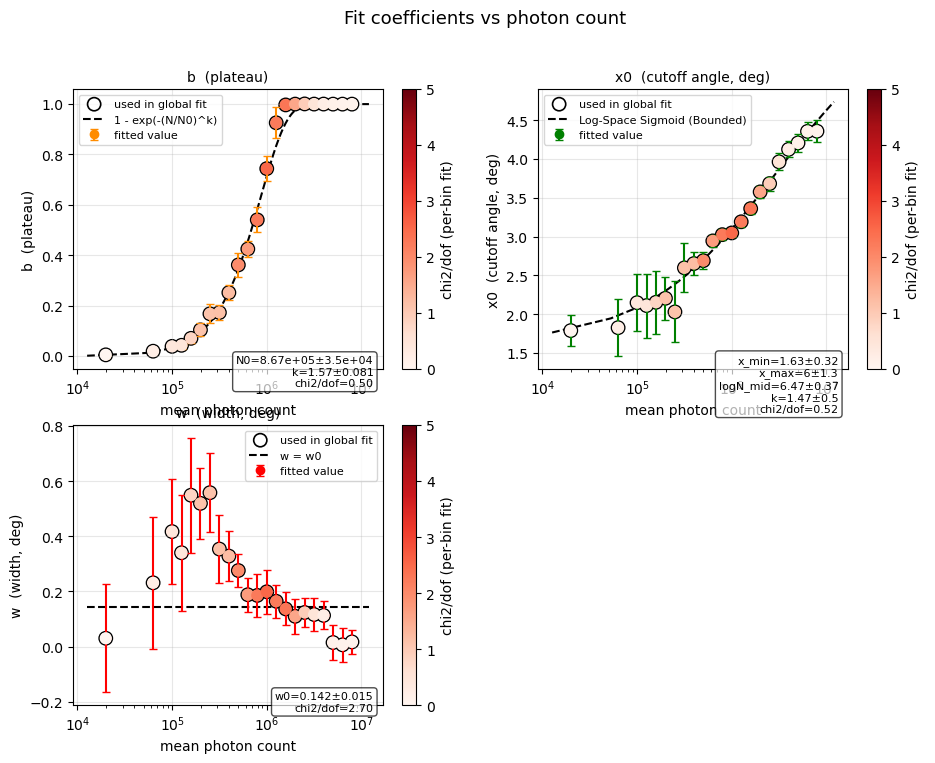


PHYSICAL MODEL FITS (coefficient vs photon count N)

--- Model for parameter 'x0' ---
Equation:  x0(N) = x_min + (x_max - x_min) / (1 + exp(-k*(log10(N) - logN_mid)))
         x_min = 1.63 ± 0.32
         x_max = 6 ± 1.3
      logN_mid = 6.466 ± 0.37
             k = 1.466 ± 0.5
      chi2/dof = 0.522

--- Model for parameter 'b' ---
Equation:  b(N)  = 1 - exp(-(N/N0)^k)
            N0 = 8.667e+05 ± 3.5e+04
             k = 1.573 ± 0.081
      chi2/dof = 0.496

--- Model for parameter 'w' ---
Equation:  w(N) = w0
            w0 = 0.142 ± 0.015
      chi2/dof = 2.702


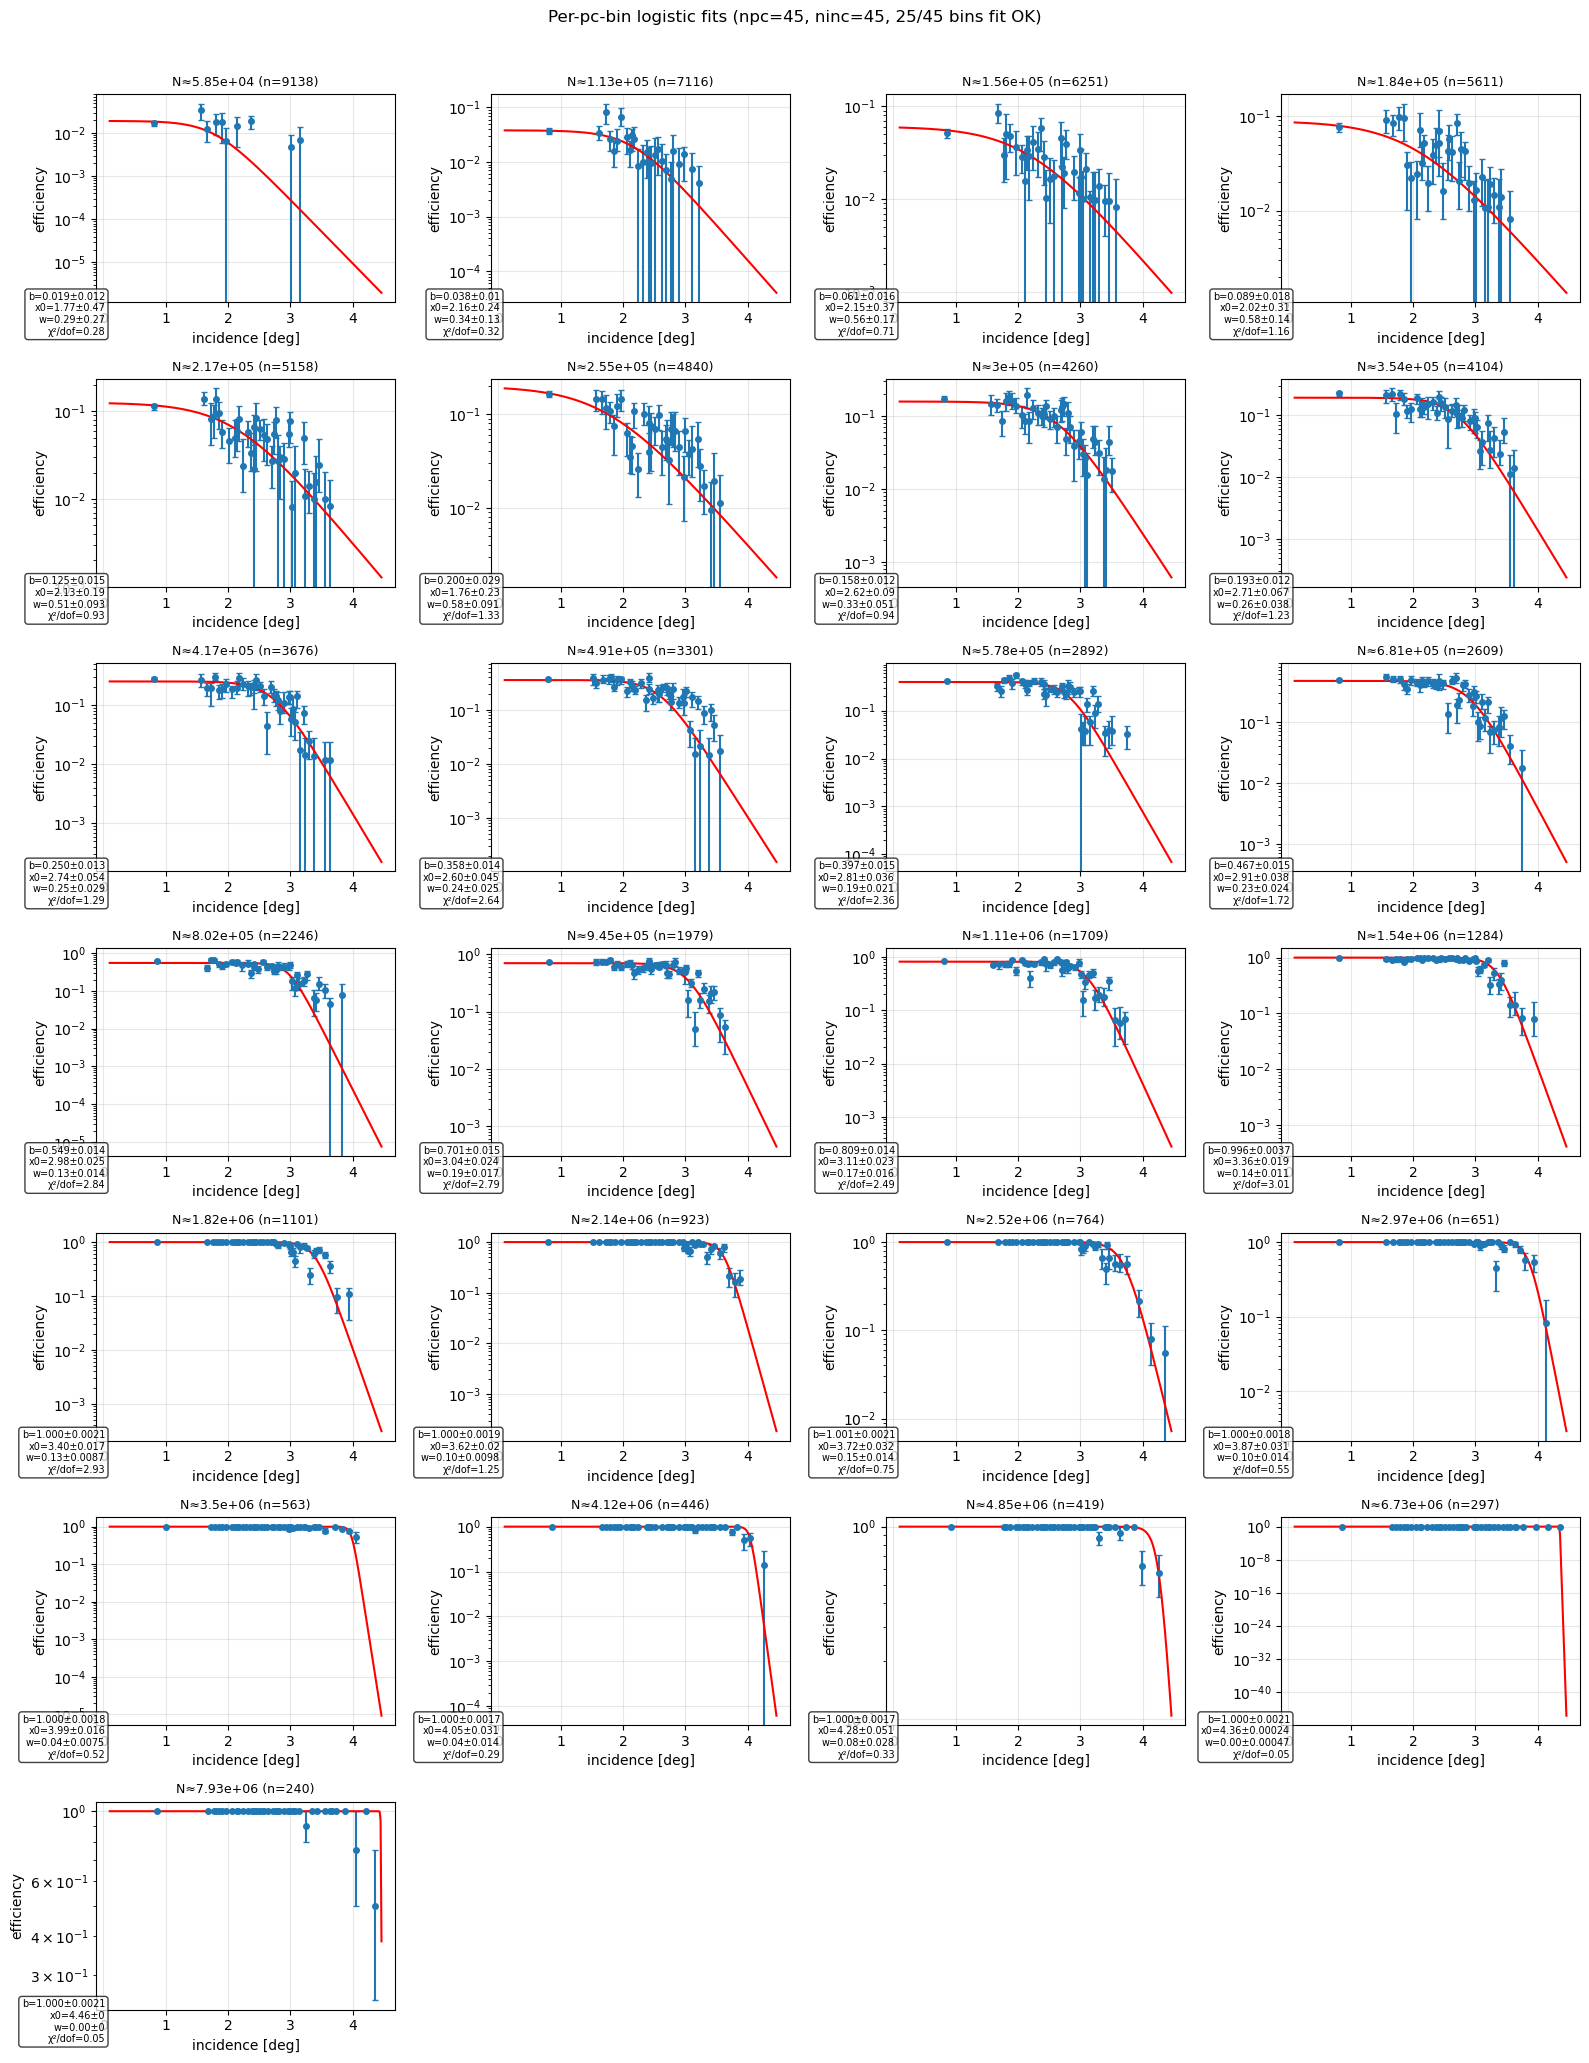

In [3]:
#Fitting Efficiency vs Incidence Model
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit, minimize

# --- User settings ---
PE_THRESHOLD = 20
n_photon_bins = 20
n_inc_bins = 20
ncols = 5
BIAS_QUANTILE = 0.2 #bias toward high incidence value
MIN_EVENTS_PER_INC_BIN = 5
MAX_CHI2_DOF = 5.0
MAX_X0_ERR_DEG = 0.5
MAX_W_ERR_DEG = 0.5
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.01
W_ERR_FLOOR = 0.01
MIN_PARAM_ERR = 1e-4
SATURATION_EFF = 0.99
B_MIN_SIGNIFICANCE = 0.09
W_MIN_BOUND = 1e-3
B_SATURATION_MAX = 0.99
X0_MODEL = "log_sigmoid"  # options: "softplus", "log", "asymptotic", "log_sigmoid"
W_MODEL = "const"  # options: "powerlaw", "const", "log_normal"
N_BIN_VARIATIONS = 50
NPC_RANGE  = (10, 80)   # range for n_photon_bins per variation
NINC_RANGE = (10, 80)     # range for n_inc_bins per variation
MIN_EVENTS_PER_PC_BIN = 5

N_BOOTSTRAP = 100
CI_LEVEL = 68.0  # percent
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0  # 0.5 for 99%

_RNG = np.random.default_rng(0)  # module-level, reproducible

# ---- bootstrap helper ----
def bootstrap_eff_ci(trig_bin, n_boot=N_BOOTSTRAP, ci_alpha=CI_ALPHA, rng=_RNG):
    n = len(trig_bin)
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan
    p_hat = float(trig_bin.mean())
    boot_effs = rng.binomial(n, p_hat, size=n_boot) / n
    lo = np.percentile(boot_effs, ci_alpha)
    hi = np.percentile(boot_effs, 100.0 - ci_alpha)
    err = max((hi - lo) / 2.0, EFF_ERR_FLOOR)
    return p_hat, lo, hi, err

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE > 0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[pe >= PE_THRESHOLD]
pc_edges = np.logspace(min(np.log10(pc_for_edges)), max(np.log10(pc_for_edges)),n_photon_bins + 1)#np.unique(np.quantile(pc_for_edges, np.linspace(0, 1, n_photon_bins + 1)))
n_photon_bins = len(pc_edges) - 1

def logistic_cutoff(x, b, x0, w):
    exponent = np.clip((x - x0) / w, -500, 500)
    return b / (1.0 + np.exp(exponent))


# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(inc_slice, trig_slice, inc_edges, rng=_RNG):
    n_bins = len(inc_edges) - 1

    # assign each event to a bin
    idx = np.digitize(inc_slice, inc_edges) - 1
    valid = (idx >= 0) & (idx < n_bins)
    idx = idx[valid]
    t   = trig_slice[valid]

    total = np.bincount(idx, minlength=n_bins).astype(int)
    hits  = np.bincount(idx, weights=t, minlength=n_bins)

    with np.errstate(invalid='ignore', divide='ignore'):
        p_hat = np.where(total > 0, hits / np.maximum(total, 1), np.nan)

    # vectorized binomial bootstrap
    safe_n = np.where(total > 0, total, 1)
    safe_p = np.where(np.isfinite(p_hat), p_hat, 0.0)
    boot = rng.binomial(safe_n[None, :], safe_p[None, :],
                        size=(N_BOOTSTRAP, n_bins)) / safe_n[None, :]

    lo = np.percentile(boot, CI_ALPHA,         axis=0)
    hi = np.percentile(boot, 100.0 - CI_ALPHA, axis=0)

    err_lo = p_hat - lo
    err_hi = hi - p_hat
    err    = np.maximum((hi - lo) / 2.0, EFF_ERR_FLOOR)

    empty = (total == 0)
    for a in (p_hat, err, err_lo, err_hi):
        a[empty] = np.nan

    return p_hat, err, err_lo, err_hi, total

def fit_one_pc_bin(pc_lo, pc_hi, inc_edges_v, rng):
    """Returns dict with keys: pc_center, popt, perr, chi2_dof, ok, n_sub.
    Returns None if bin has too few events or fit fails."""
    sub = (pc >= pc_lo) & (pc < pc_hi)
    n_sub = int(sub.sum())
    if n_sub < MIN_EVENTS_PER_PC_BIN:
        return None

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    ninc = len(inc_edges_v) - 1
    if ninc < 1:
        return None
    inc_threshold = np.quantile(inc_sub, BIAS_QUANTILE)
    inc_upper = inc_sub[inc_sub >= inc_threshold]
    if len(inc_upper) >= ninc:
        inc_edges_upper = np.unique(
            np.quantile(inc_upper, np.linspace(0, 1, ninc + 1))
        )
        inc_edges_i = np.unique(np.concatenate([[inc_sub.min()], inc_edges_upper]))
    else:
        inc_edges_i = inc_edges_v

    if len(inc_edges_i) < 3:
        return None

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges_i, rng=rng
    )
    inc_centers = 0.5 * (inc_edges_i[:-1] + inc_edges_i[1:])

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))

    good = np.isfinite(eff) & (total >= MIN_EVENTS_PER_INC_BIN)
    if good.sum() < 4:
        return None

    xd = inc_centers[good]
    yd = eff[good]
    sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

    inc_range = inc_edges_i[-1] - inc_edges_i[0]
    b0 = min(max(np.nanmax(yd), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
    w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
    p0 = [b0, x0_0, w0]
    bounds = (
        [0.0, inc_edges_i[0], 1e-3],
        [1.05, inc_edges_i[-1], 0.4 * inc_range],
    )

    try:
        popt, pcov = curve_fit(
            logistic_cutoff, xd, yd, p0=p0, sigma=sd,
            absolute_sigma=True, bounds=bounds, maxfev=20000
        )
    except Exception:
        return None

    perr = np.sqrt(np.diag(pcov))
    y_model = logistic_cutoff(xd, *popt)
    chi2 = np.sum(((yd - y_model) / sd) ** 2)
    dof = len(xd) - 3
    chi2_dof = chi2 / dof if dof > 0 else np.nan

    ok = True
    if not np.isfinite(chi2_dof):
        ok = False
    if chi2_dof >= MAX_CHI2_DOF:
        ok = False
    if perr[1] >= MAX_X0_ERR_DEG or perr[2] >= MAX_W_ERR_DEG:
        ok = False
    if saturated:
        ok = False

    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0
    return {
        "pc_center": np.sqrt(pc_lo * pc_hi),
        "popt": popt,
        "perr": perr,
        "chi2_dof": chi2_dof,
        "ok": ok,
        "n_sub": n_sub,
        "inc_centers": inc_centers,
        "eff": eff,
        "err": err,
        "err_lo": err_lo,
        "err_hi": err_hi,
        "total": total,
        "good": good,
        "min_total": min_total,
        "saturated": saturated,
        "n_bins_actual": len(inc_edges_i) - 1,
    }

# ======================================================================
# Bin-variation loop (binning systematic)
# ======================================================================
agg = defaultdict(list)
agg_perr = defaultdict(list)
agg_chi2 = defaultdict(list)
agg_nsub = defaultdict(list)

log_pc_min = np.log10(pc_for_edges.min())
log_pc_max = np.log10(pc_for_edges.max())

if N_BIN_VARIATIONS == 1:
    bin_results = []

for v in range(N_BIN_VARIATIONS):
    rng_v = np.random.default_rng(1000 + v)
    if N_BIN_VARIATIONS == 1:
        npc = n_photon_bins
        ninc = n_inc_bins
    else:
        npc  = int(rng_v.integers(NPC_RANGE[0],  NPC_RANGE[1]  + 1))
        ninc = int(rng_v.integers(NINC_RANGE[0], NINC_RANGE[1] + 1))

    pc_edges_v = np.logspace(log_pc_min, log_pc_max, npc + 1)

    for i in range(npc):
        pc_lo, pc_hi = pc_edges_v[i], pc_edges_v[i + 1]
        sub = (pc >= pc_lo) & (pc < pc_hi)
        n_sub = int(sub.sum())
        if n_sub < MIN_EVENTS_PER_PC_BIN:
            if N_BIN_VARIATIONS == 1:
                bin_results.append({
                    "pc_lo": pc_lo, "pc_hi": pc_hi, "n_sub": n_sub,
                    "skip_reason": "low_events",
                })
            continue

        inc_sub = inc[sub]
        inc_edges_v = np.unique(np.quantile(inc_sub, np.linspace(0, 1, ninc + 1)))
        if len(inc_edges_v) < 4:
            if N_BIN_VARIATIONS == 1:
                bin_results.append({
                    "pc_lo": pc_lo, "pc_hi": pc_hi, "n_sub": n_sub,
                    "skip_reason": "insufficient_bins",
                })
            continue

        res = fit_one_pc_bin(pc_lo, pc_hi, inc_edges_v, rng_v)
        if N_BIN_VARIATIONS == 1:
            entry = {"pc_lo": pc_lo, "pc_hi": pc_hi, "n_sub": n_sub}
            if res is None:
                entry["skip_reason"] = "fit_failed"
            else:
                entry.update(res)
            bin_results.append(entry)

        if res is None or not res["ok"]:
            continue

        key = round(np.log10(res["pc_center"]), 1)
        agg[key].append(res["popt"])
        agg_perr[key].append(res["perr"])
        agg_chi2[key].append(res["chi2_dof"])
        agg_nsub[key].append(res["n_sub"])

# ======================================================================
# Aggregate across binning variations
# ======================================================================
keys_sorted = sorted(agg.keys())
pc_means   = np.array([10**k for k in keys_sorted])

b_vals  = np.array([np.median([p[0] for p in agg[k]]) for k in keys_sorted])
x0_vals = np.array([np.median([p[1] for p in agg[k]]) for k in keys_sorted])
w_vals  = np.array([np.median([p[2] for p in agg[k]]) for k in keys_sorted])

def _combined_err(popts, perrs, idx):
    vals = np.array([p[idx] for p in popts])
    stat = np.array([e[idx] for e in perrs])
    syst = vals.std(ddof=1) if len(vals) > 1 else 0.0
    return np.sqrt(np.median(stat)**2 + syst**2)

b_errs  = np.array([_combined_err(agg[k], agg_perr[k], 0) for k in keys_sorted])
x0_errs = np.array([_combined_err(agg[k], agg_perr[k], 1) for k in keys_sorted])
w_errs  = np.array([_combined_err(agg[k], agg_perr[k], 2) for k in keys_sorted])

chi2_vals = np.array([np.median(agg_chi2[k]) for k in keys_sorted])
n_variations_per_key = np.array([len(agg[k]) for k in keys_sorted])

quality_mask = (
    np.isfinite(b_vals) & np.isfinite(x0_vals) & np.isfinite(w_vals) &
    (chi2_vals < MAX_CHI2_DOF) &
    (n_variations_per_key >= max(3, N_BIN_VARIATIONS // 4))
)

min_counts = np.array([int(np.median(agg_nsub[k])) for k in keys_sorted])
mean_counts = np.array([float(np.mean(agg_nsub[k])) for k in keys_sorted])

# ======================================================================
# PLOT: trigger efficiency per photon-count bin (single variation only)
# ======================================================================
if N_BIN_VARIATIONS == 1:
    nrows = int(np.ceil(n_photon_bins / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes).ravel()
    x_fit = np.linspace(inc.min(), inc.max(), 200)

    for i in range(n_photon_bins):
        ax = axes[i]
        r = bin_results[i]
        pc_lo, pc_hi = r["pc_lo"], r["pc_hi"]
        n_sub = r["n_sub"]

        if n_sub == 0:
            ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN=0")
            continue

        if r.get("skip_reason") == "low_events":
            ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN={n_sub}")
            ax.text(0.5, 0.5, f"low stats (min N={MIN_EVENTS_PER_PC_BIN})",
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=7, color='darkred')
            continue
        if r.get("skip_reason") == "insufficient_bins":
            ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN={n_sub}")
            ax.text(0.5, 0.5, "insufficient bins", transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='red')
            continue
        if r.get("skip_reason") == "fit_failed":
            ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN={n_sub}")
            ax.text(0.5, 0.5, "fit failed", transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='red')
            continue

        inc_centers = r["inc_centers"]
        eff = r["eff"]
        err_lo = r["err_lo"]
        err_hi = r["err_hi"]
        n_bins_actual = r["n_bins_actual"]

        yerr_asym = np.array([
            np.where(np.isfinite(err_lo), err_lo, 0),
            np.where(np.isfinite(err_hi), err_hi, 0)
])

        ax.errorbar(inc_centers, eff, yerr=yerr_asym, fmt='o', capsize=2,
                    label=f"~{n_sub // n_bins_actual} per bin (bootstrap {CI_LEVEL:.0f}% CI)")

        if r.get("saturated", False):
            ax.text(0.05, 0.05, f"saturated (eff>={SATURATION_EFF:.2f})",
                    transform=ax.transAxes, fontsize=7, color='darkred')
        else:
            good = r.get("good", np.array([], dtype=bool))
            min_total = r.get("min_total", 0)
            if good.sum() >= 4 and min_total >= MIN_EVENTS_PER_INC_BIN:
                if r.get("ok", False):
                    popt = r["popt"]
                    chi2_dof = r["chi2_dof"]
                    ax.plot(x_fit, logistic_cutoff(x_fit, *popt), 'r-', lw=1.5,
                            label=(f"b={popt[0]:.2g}, x0={popt[1]:.2f}, "
                                   f"w={popt[2]:.2f}\nchi2/dof={chi2_dof:.2f}"))
                else:
                    ax.text(0.05, 0.05, "fit failed", transform=ax.transAxes,
                            fontsize=8, color='red')
            else:
                ax.text(0.05, 0.05, f"low stats (min N={min_total})",
                        transform=ax.transAxes, fontsize=7, color='darkred')

        ax.legend(fontsize=7, loc='lower left')
        ax.set_ylim(1e-5, 1.2)
        ax.set_yscale("log")
        ax.set_title(f"photon_count in [{pc_lo:.1e}, {pc_hi:.1e}]\nN={n_sub}", fontsize=9)
        ax.grid(alpha=0.3)

    for j in range(n_photon_bins, len(axes)):
        axes[j].set_visible(False)

    for ax in axes[:n_photon_bins]:
        if ax.get_subplotspec().is_last_row():
            ax.set_xlabel("Incidence angle (deg)")
        if ax.get_subplotspec().is_first_col():
            ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")

    fig.suptitle(f"Trigger efficiency vs incidence | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    saturated_bins = [
        (np.sqrt(r["pc_lo"] * r["pc_hi"]), r["n_sub"])
        for r in bin_results if r.get("saturated", False)
    ]
    if saturated_bins:
        print("Skipped saturated bins (eff ~ 1 across incidence):")
        for pc_mean, n_sub in saturated_bins:
            print(f"  pc_mean={pc_mean:.3e}, N={n_sub}")

# -- quality mask --
finite_mask = np.isfinite(b_vals) & np.isfinite(x0_vals) & np.isfinite(w_vals)
stats_mask = n_variations_per_key >= max(3, N_BIN_VARIATIONS // 4)
chi2_mask = chi2_vals < MAX_CHI2_DOF
quality_mask = finite_mask & stats_mask & chi2_mask

# -- diagnostics print --
print("=" * 80)
print("PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS")
print("=" * 80)
print("Fit equation: eff(x) = b / (1 + exp((x - x0) / w))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'pc_mean':>12} {'b':>10} {'±b':>10} {'x0':>10} {'±x0':>10} "
      f"{'w':>10} {'±w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(pc_means)):
    print(f"{pc_means[i]:12.3e} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:10.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(pc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)

dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'pc_mean':>12} {'b/σ_b':>8} {'chi2/dof':>10} {'minN':>8}  reasons")
    min_req = max(3, N_BIN_VARIATIONS // 4)
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]: reasons.append("nonfinite")
        if not stats_mask[i]:  reasons.append(f"minN<{min_req}")
        if not chi2_mask[i]:   reasons.append(f"chi2>{MAX_CHI2_DOF}")
        bs = b_vals[i] / b_errs[i] if np.isfinite(b_errs[i]) and b_errs[i] > 0 else 0.0
        print(f"{pc_means[i]:12.3e} {bs:8.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

# -- physical models --
def x0_softplus(N, x0_lo, Nt, s, p):
    N = np.maximum(N, 1e-12)
    Nt = np.maximum(Nt, 1e-12)
    return x0_lo + s * np.log1p((N / Nt) ** p)
    
def x0_log(N, a, b_coef):
    return a + b_coef * np.log10(N)

def x0_asymptotic(N, theta_max, A, k):
    N = np.maximum(N, 0.0)
    return theta_max - A * np.exp(-k * N)

def x0_log_sigmoid(N, x_min, x_max, logN_mid, k):
    N = np.maximum(N, 1e-12)
    logN = np.log10(N)
    return x_min + (x_max - x_min) / (1.0 + np.exp(-k * (logN - logN_mid)))

x0_model_cfg = {
    "softplus": {
        "fn": x0_softplus,
        "p0": [3.0, 1e6, 0.5, 2.0],
        "bounds": ([2.0, 1e5, 0.0, 0.5], [5.0, 1e7, 5.0, 10.0]),
        "label": r"x0_lo + s*log1p((N/Nt)^p)",
        "param_names": ["x0_lo", "Nt", "s", "p"],
    },
    "log": {
        "fn": x0_log,
        "p0": [3.0, 0.5],
        "bounds": ([0.0, -5.0], [10.0, 5.0]),
        "label": r"a + b*log10(N)",
        "param_names": ["a", "b"],
    },
    "asymptotic": {
        "fn": x0_asymptotic,
        "p0": [30.0, 10.0, 0.05],
        "bounds": ([0.0, 0.0, 0.0001], [15.0, 30.0, 1.0]),
        "label": "Asymptotic (Physical Limit)",
        "param_names": ["theta_max", "A", "k"],
    },
    "log_sigmoid": {
        "fn": x0_log_sigmoid,
        "p0": [2.8, 4.5, 6.3, 3.0],
        "bounds": ([0.0, 3.5, 5.0, 0.1], [3.5, 6.0, 7.5, 10.0]),
        "label": "Log-Space Sigmoid (Bounded)",
        "param_names": ["x_min", "x_max", "logN_mid", "k"],
    },
}

if X0_MODEL not in x0_model_cfg:
    raise ValueError(
        f"Unknown X0_MODEL='{X0_MODEL}'. Use 'softplus', 'log', 'asymptotic', or 'log_sigmoid'."
    )
x0_model = x0_model_cfg[X0_MODEL]
x0_model_fn = x0_model["fn"]

def plateau_model(N, N0, k):
    N = np.maximum(N, 1e-12)
    return 1.0 - np.exp(-(N / N0) ** k)

def w_powerlaw(N, w_inf, A, alpha):
    N = np.maximum(N, 1e-12)
    return w_inf + A * N**(-alpha)

def w_const(N, w0):
    N = np.maximum(N, 1e-12)
    return np.full_like(N, w0, dtype=float)

def w_log_normal(N, baseline, amplitude, logN_peak, sigma):
    N = np.maximum(N, 1e-12)
    logN = np.log10(N)
    peak = amplitude * np.exp(-0.5 * ((logN - logN_peak) / sigma) ** 2)
    return baseline + peak

w_model_cfg = {
    "powerlaw": {
        "fn": w_powerlaw,
        "p0": [0.05, 50.0, 0.5],
        # w_inf can be exactly 0. Upper bounds opened slightly.
        "bounds": ([0.0, 0.0, 0.05], [0.5, 1e6, 2.0]),
        "label": r"w_inf + A*N^(-alpha)",
        "eq": "w(N) = w_inf + A * N**(-alpha)",
        "param_names": ["w_inf", "A", "alpha"],
    },
    "const": {
        "fn": w_const,
        "p0": [0.15],
        # Safely covers any reasonable constant smearing
        "bounds": ([0.0], [1.5]),
        "label": r"w = w0",
        "eq": "w(N) = w0",
        "param_names": ["w0"],
    },
    "log_normal": {
        "fn": w_log_normal,
        # Updated p0 amplitude to 0.6 based on your raw data peaking around 0.6
        "p0": [0.01, 0.6, 5.5, 0.5], 
        # baseline: lowered to 0.0 (prevents hitting the 0.001 wall)
        # amplitude: widened to 2.0 just in case
        # logN_peak: widened to [4.0, 7.0] to cover your whole valid N range
        "bounds": ([0.0, 0.1, 4.0, 0.1], [0.5, 2.0, 7.0, 2.5]),
        "label": "Log-Normal Peak",
        "eq": "w(N) = baseline + amplitude * exp(-0.5*((log10(N) - logN_peak)/sigma)**2)",
        "param_names": ["baseline", "amplitude", "logN_peak", "sigma"],
    },
}


if W_MODEL not in w_model_cfg:
    raise ValueError(f"Unknown W_MODEL='{W_MODEL}'. Use 'powerlaw', 'const', or 'log_normal'.")
w_model = w_model_cfg[W_MODEL]
w_model_fn = w_model["fn"]

results = {}

def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof

ok_x0 = quality_mask & np.isfinite(x0_errs) #old
#ok_x0 = quality_mask & np.isfinite(x0_errs) & (x0_errs < 0.3)  # was just isfinite

try:
    popt, perr, pcov, c2 = fit_model(
        x0_model_fn, pc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=x0_model["p0"],
        bounds=x0_model["bounds"],
    )
    results['x0'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"x0 model fit failed: {e}")

ok_b = quality_mask & (b_vals < B_SATURATION_MAX) & np.isfinite(b_errs) #old
"""ok_b = (
    quality_mask &
    (b_vals < B_SATURATION_MAX) &
    np.isfinite(b_errs) &
    (b_errs < 0.1) &          # tighter error cut
    (b_vals / b_errs > 3.0)   # stricter significance (was 0.09)
)"""
try:
    popt, perr, pcov, c2 = fit_model(
        plateau_model, pc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=[np.median(pc_means[ok_b]), 1.0],
        bounds=([pc_means.min() * 0.1, 0.1], [pc_means.max() * 10.0, 10.0])
    )
    results['b'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"b model fit failed: {e}")

ok_w = quality_mask & np.isfinite(w_errs) & (w_vals > 0)
try:
    popt, perr, pcov, c2 = fit_model(
        w_model_fn, pc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=w_model["p0"],
        bounds=w_model["bounds"]
    )
    results['w'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"w model fit failed: {e}")

# -- comparison plot --
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
N_smooth = np.linspace(pc_means.min() * 0.8, pc_means.max() * 1.2, 300)

labels      = ['b  (plateau)', 'x0  (cutoff angle, deg)', 'w  (width, deg)']
yvals       = [b_vals, x0_vals, w_vals]
yerrs       = [b_errs, x0_errs, w_errs]
colors      = ['darkorange', 'green', 'red']
model_keys  = ['b', 'x0', 'w']
model_fns   = [plateau_model, x0_model_fn, w_model_fn]
model_labels = {
    'x0': x0_model["label"],
    'b':  r"1 - exp(-(N/N0)^k)",
    'w':  w_model["label"],
}
param_names = {
    'x0': x0_model["param_names"],
    'b':  ['N0', 'k'],
    'w':  w_model["param_names"],
}

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(pc_means[qm], yv[qm], yerr=ye[qm], fmt='o', color=col,
                capsize=3, label='fitted value', zorder=3)
    sc = ax.scatter(pc_means[qm], yv[qm], c=chi2_vals[qm], cmap='Reds',
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label='chi2/dof (per-bin fit)')
    ax.scatter(pc_means[qm], yv[qm],
               facecolors='none', edgecolors='black', s=90,
               linewidths=1.2, label='used in global fit')

    if mkey in results:
        popt, perr, pcov, c2 = results[mkey]
        ax.plot(N_smooth, mfn(N_smooth, *popt), 'k--',
                lw=1.5, label=model_labels[mkey])
        txt = "\n".join(f"{n}={v:.3g}±{e:.2g}"
                        for n, v, e in zip(param_names[mkey], popt, perr))
        txt += f"\nchi2/dof={c2:.2f}"
        ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                ha='right', va='top',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    ax.set_xscale('log')
    ax.set_xlabel('mean photon count')
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis('off')

fig.suptitle("Fit coefficients vs photon count", fontsize=13)
#fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# -- physical model summary --
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs photon count N)")
print("=" * 80)
model_equations = {
    'x0': (
        "x0(N) = x_min + (x_max - x_min) / (1 + exp(-k*(log10(N) - logN_mid)))" if X0_MODEL == "log_sigmoid" else
        "x0(N) = x0_lo + s * log1p((N/Nt)^p)" if X0_MODEL == "softplus" else
        "x0(N) = theta_max - A * exp(-k * N)" if X0_MODEL == "asymptotic" else
        "x0(N) = a + b * log10(N)"
    ),
    'b':  "b(N)  = 1 - exp(-(N/N0)^k)",
    'w':  w_model["eq"],
}
for key in ['x0', 'b', 'w']:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, pcov, c2 = results[key]
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} ± {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)
# --- Plot per-pc-bin efficiency curves and logistic fits ---
import numpy as np
import matplotlib.pyplot as plt

# Use a representative variation: median bin counts
npc_plot  = int(np.median(NPC_RANGE))
ninc_plot = int(np.median(NINC_RANGE))

log_pc_min = np.log10(pc_for_edges.min())
log_pc_max = np.log10(pc_for_edges.max())
pc_edges_plot = np.logspace(log_pc_min, log_pc_max, npc_plot + 1)

# dummy inc_edges_v just for the function signature (function rebuilds internally)
inc_edges_dummy = np.linspace(inc.min(), inc.max(), ninc_plot + 1)

# Collect successful fits
plot_results = []
for i in range(npc_plot):
    res = fit_one_pc_bin(pc_edges_plot[i], pc_edges_plot[i+1],
                         inc_edges_dummy, _RNG)
    if res is not None and res.get('ok', False):
        plot_results.append(res)

n_plots = len(plot_results)
if n_plots == 0:
    print("No successful per-bin fits to plot.")
else:
    ncols_p = 4
    nrows_p = int(np.ceil(n_plots / ncols_p))
    fig, axes = plt.subplots(nrows_p, ncols_p,
                             figsize=(4*ncols_p, 3*nrows_p),
                             squeeze=False)
    axes = axes.flatten()

    inc_smooth = np.linspace(inc.min(), inc.max(), 300)

    for ax, res in zip(axes, plot_results):
        ic   = res['inc_centers']
        eff  = res['eff']
        elo  = res['err_lo']
        ehi  = res['err_hi']
        popt = res['popt']
        perr = res['perr']
        c2   = res['chi2_dof']
        pc_c = res['pc_center']

        yerr = np.vstack([elo, ehi])


        ax.errorbar(ic, eff, yerr=yerr, fmt='o', color='C0',
                    capsize=2, ms=4, label='data')

        ax.plot(inc_smooth, logistic_cutoff(inc_smooth, *popt),
                'r-', lw=1.5, label='fit')

        b, x0, w = popt
        be, x0e, we = perr
        txt = (f"b={b:.3f}±{be:.2g}\n"
               f"x0={x0:.2f}±{x0e:.2g}\n"
               f"w={w:.2f}±{we:.2g}\n"
               f"χ²/dof={c2:.2f}")
        ax.text(0.03, 0.05, txt, transform=ax.transAxes,
                fontsize=7, va='top', ha='right',
                bbox=dict(boxstyle='round', fc='white', alpha=0.75))

        ax.set_title(f"N≈{pc_c:.3g} (n={res['n_sub']})", fontsize=9)
        ax.set_xlabel('incidence [deg]')
        ax.set_ylabel('efficiency')
        #ax.set_ylim(-0.05, 1.1)
        ax.set_yscale("log")
        ax.grid(alpha=0.3)

    for ax in axes[n_plots:]:
        ax.axis('off')

    fig.suptitle(f"Per-pc-bin logistic fits "
                 f"(npc={npc_plot}, ninc={ninc_plot}, "
                 f"{n_plots}/{npc_plot} bins fit OK)",
                 fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [ ]:
# Bootstrap with combined statistical + binning systematics - store med/lo/hi only
# =============================================================================
import os
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, map_coordinates

# ---------- Config ----------
N_BOOT   = N_BOOTSTRAP
#CI_LEVEL = 68  # 99.7 ~ 3 sigma, 95 ~ 2 sigma, 68 ~ 1 sigma
N_JOBS   = os.cpu_count()
SEED     = 0
MIN_CNT  = 20

NPC_RANGE    = (10, 50)
NINC_RANGE   = (10, 50)
SMOOTH_RANGE = (0.7, 0.9)
LOG10_PC_MIN_RANGE = (np.log10(pc_.min()), 3)  # 3.8

if "W_MODEL" not in globals():
    W_MODEL = "powerlaw"

    # Legacy grid sizes for initial empirical cube (kept for step order)
    N_COMMON_PC_DATA  = 50
    N_COMMON_INC_DATA = 50

    # ---------- Worker ----------
    def build_interp_from_edges(pc_s, inc_s, hit_s,
                                pc_edges, inc_edges, smooth, min_cnt=MIN_CNT):
                                    pc_cen  = np.sqrt(pc_edges[:-1] * pc_edges[1:])
                                        inc_cen = 0.5 * (inc_edges[:-1] + inc_edges[1:])
                                            N_tot, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges])
                                                N_hit, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges],
                                                                                 weights=hit_s)
                                                                                     with np.errstate(invalid='ignore', divide='ignore'):
                                                                                             e = np.where(N_tot >= min_cnt, N_hit / N_tot, np.nan)
                                                                                                 mask = np.isfinite(e)
                                                                                                     e_filled = np.where(mask, e, 0.0)
                                                                                                         w = mask.astype(float)
                                                                                                             e_smooth = gaussian_filter(e_filled, sigma=smooth) / np.clip(
                                                                                                                     gaussian_filter(w, sigma=smooth), 1e-6, None)
                                                                                                                         return RegularGridInterpolator(
                                                                                                                                 (np.log10(pc_cen), inc_cen), e_smooth,
                                                                                                                                         bounds_error=False, fill_value=None, method='linear')

                                                                                                                                         def _one_boot(seed, pc_, inc_, hit_):
                                                                                                                                             rng = np.random.default_rng(seed)
                                                                                                                                                 n = pc_.shape[0]
                                                                                                                                                     idx = rng.integers(0, n, size=n)
                                                                                                                                                         pcs, incs, hits = pc_[idx], inc_[idx], hit_[idx]
                                                                                                                                                             npc    = rng.integers(NPC_RANGE[0],  NPC_RANGE[1]  + 1)
                                                                                                                                                                 ninc   = rng.integers(NINC_RANGE[0], NINC_RANGE[1] + 1)
                                                                                                                                                                     smooth = rng.uniform(*SMOOTH_RANGE)
                                                                                                                                                                         log_lo = rng.uniform(*LOG10_PC_MIN_RANGE)
                                                                                                                                                                             pc_edges  = np.logspace(log_lo, np.log10(pc_.max()), npc + 1)
                                                                                                                                                                                 inc_edges = np.linspace(inc_.min(), inc_.max(), ninc + 1)
                                                                                                                                                                                     return build_interp_from_edges(pcs, incs, hits, pc_edges, inc_edges, smooth)

                                                                                                                                                                                     # ---------- Nominal ----------
                                                                                                                                                                                     pc_edges_nom  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 80 + 1)
                                                                                                                                                                                     inc_edges_nom = np.linspace(inc_.min(), inc_.max(), 15 + 1)
                                                                                                                                                                                     interp = build_interp_from_edges(pc_, inc_, hit_,
                                                                                                                                                                                                                      pc_edges_nom, inc_edges_nom, smooth=0.8)

                                                                                                                                                                                                                      # ---------- Bootstrap ----------
                                                                                                                                                                                                                      ss = np.random.SeedSequence(SEED)
                                                                                                                                                                                                                      seeds = [s.generate_state(1)[0] for s in ss.spawn(N_BOOT)]
                                                                                                                                                                                                                      print(f"Running {N_BOOT} bootstrap replicas on {N_JOBS} CPUs...")
                                                                                                                                                                                                                      boot_interps = Parallel(n_jobs=N_JOBS, verbose=5)(
                                                                                                                                                                                                                          delayed(_one_boot)(s, pc_, inc_, hit_) for s in seeds
                                                                                                                                                                                                                          )
                                                                                                                                                                                                                          print(f"Done: {len(boot_interps)} interpolators built.")

                                                                                                                                                                                                                          # ---------- Legacy empirical cube (kept so Step 1 can follow order) ----------
                                                                                                                                                                                                                          COMMON_LOG_PC_DATA = np.linspace(np.log10(pc_.min()), np.log10(pc_.max()), N_COMMON_PC_DATA)
                                                                                                                                                                                                                          COMMON_INC_DATA    = np.linspace(inc_.min(),          inc_.max(),          N_COMMON_INC_DATA)
                                                                                                                                                                                                                          _PC2D_DATA, _INC2D_DATA = np.meshgrid(COMMON_LOG_PC_DATA, COMMON_INC_DATA, indexing='ij')
                                                                                                                                                                                                                          _grid_pts_data = np.column_stack([_PC2D_DATA.ravel(), _INC2D_DATA.ravel()])
                                                                                                                                                                                                                          _cube = np.empty((N_BOOT, N_COMMON_PC_DATA, N_COMMON_INC_DATA), dtype=np.float32)
                                                                                                                                                                                                                          for b, bi in enumerate(boot_interps):
                                                                                                                                                                                                                              _cube[b] = np.clip(bi(_grid_pts_data), 0.0, 1.0).reshape(
                                                                                                                                                                                                                                      N_COMMON_PC_DATA, N_COMMON_INC_DATA)

                                                                                                                                                                                                                                      # ---------- Step 1: Parametric model helpers ----------
                                                                                                                                                                                                                                      def _b_of_N(N, params):
                                                                                                                                                                                                                                          N0, k = params
                                                                                                                                                                                                                                              return 1.0 - np.exp(-(N / N0) ** k)

                                                                                                                                                                                                                                              def _x0_of_N(N, params):
                                                                                                                                                                                                                                                  if X0_MODEL == "log":
                                                                                                                                                                                                                                                          a, b = params
                                                                                                                                                                                                                                                                  return a + b * np.log10(N)
                                                                                                                                                                                                                                                                      if X0_MODEL == "log_sigmoid":
                                                                                                                                                                                                                                                                              x_min, x_max, logN_mid, k = params
                                                                                                                                                                                                                                                                                      N = np.maximum(N, 1e-12)
                                                                                                                                                                                                                                                                                              logN = np.log10(N)
                                                                                                                                                                                                                                                                                                      return x_min + (x_max - x_min) / (1.0 + np.exp(-k * (logN - logN_mid)))
                                                                                                                                                                                                                                                                                                          if X0_MODEL == "softplus":
                                                                                                                                                                                                                                                                                                                  x0_lo, s, Nt, p = params
                                                                                                                                                                                                                                                                                                                          Nt = max(Nt, 1e-12)              # guard
                                                                                                                                                                                                                                                                                                                                  ratio = np.maximum(N / Nt, 0.0)  # guard
                                                                                                                                                                                                                                                                                                                                          return x0_lo + s * np.log1p((N / Nt) ** p)
                                                                                                                                                                                                                                                                                                                                              if X0_MODEL == "asymptotic":
                                                                                                                                                                                                                                                                                                                                                      theta_max, A, k = params
                                                                                                                                                                                                                                                                                                                                                              N = np.maximum(N, 0.0)
                                                                                                                                                                                                                                                                                                                                                                      return theta_max - A * np.exp(-k * N)
                                                                                                                                                                                                                                                                                                                                                                          raise ValueError(f"Unsupported X0_MODEL: {X0_MODEL}")

                                                                                                                                                                                                                                                                                                                                                                          def _w_of_N(N, params):
                                                                                                                                                                                                                                                                                                                                                                              N = np.maximum(N, 1e-12)
                                                                                                                                                                                                                                                                                                                                                                                  if W_MODEL == "powerlaw":
                                                                                                                                                                                                                                                                                                                                                                                          w_inf, A, alpha_p = params
                                                                                                                                                                                                                                                                                                                                                                                                  return w_inf + A * N ** (-alpha_p)
                                                                                                                                                                                                                                                                                                                                                                                                      if W_MODEL == "const":
                                                                                                                                                                                                                                                                                                                                                                                                              (w0,) = params
                                                                                                                                                                                                                                                                                                                                                                                                                      return np.full_like(N, w0, dtype=float)
                                                                                                                                                                                                                                                                                                                                                                                                                          if W_MODEL == "log_normal":
                                                                                                                                                                                                                                                                                                                                                                                                                                  baseline, amplitude, logN_peak, sigma = params
                                                                                                                                                                                                                                                                                                                                                                                                                                          logN = np.log10(N)
                                                                                                                                                                                                                                                                                                                                                                                                                                                  peak = amplitude * np.exp(-0.5 * ((logN - logN_peak) / sigma) ** 2)
                                                                                                                                                                                                                                                                                                                                                                                                                                                          return baseline + peak
                                                                                                                                                                                                                                                                                                                                                                                                                                                              raise ValueError(f"Unsupported W_MODEL: {W_MODEL}")

                                                                                                                                                                                                                                                                                                                                                                                                                                                              def _parametric_eff(N, theta, b_p, x0_p, w_p): #clip 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                  b   = np.clip(_b_of_N(N, b_p), 0.0, 1.0)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                      x0  = _x0_of_N(N, x0_p)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                          w   = np.maximum(_w_of_N(N, w_p), 1e-3)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  # Clip exponent to prevent np.exp overflow
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      exponent = np.clip((theta - x0) / w, -500, 500)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          return b / (1.0 + np.exp(exponent))

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          # ---------- Step 2: Extended common grid ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _DATA_LOG_PC_LO = np.log10(pc_.min())
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _DATA_LOG_PC_HI = np.log10(pc_.max())
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _DATA_INC_LO    = inc_.min()
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _DATA_INC_HI    = inc_.max()

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          N_COMMON_PC  = 50
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          N_COMMON_INC = 50
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          COMMON_LOG_PC = np.linspace(_DATA_LOG_PC_LO - 1.0, _DATA_LOG_PC_HI + 2.0, N_COMMON_PC)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          COMMON_INC    = np.linspace(0.0, 10.0, N_COMMON_INC)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          # ---------- Step 3: Coverage mask on extended grid ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _PC2D, _INC2D = np.meshgrid(COMMON_LOG_PC, COMMON_INC, indexing='ij')
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _inside = (
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              (_PC2D >= _DATA_LOG_PC_LO) & (_PC2D <= _DATA_LOG_PC_HI) &
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  (_INC2D >= _DATA_INC_LO)   & (_INC2D <= _DATA_INC_HI)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  ).astype(np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  COV = gaussian_filter(_inside, sigma=2.0)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  COV = np.clip(COV, 0.0, 1.0).astype(np.float32)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  # ---------- Step 4: Parametric samples for uncertainty ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  rng_param = np.random.default_rng(SEED + 1)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  def _sample_param_realizations(n_samples, max_tries=50):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      b_mean,  b_cov  = results['b'][0],  results['b'][2]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          x0_mean, x0_cov = results['x0'][0], results['x0'][2]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              w_mean,  w_cov  = results['w'][0],  results['w'][2]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  samples = []
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      for _ in range(n_samples):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              for _try in range(max_tries):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          bp = rng_param.multivariate_normal(b_mean,  b_cov)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      xp = rng_param.multivariate_normal(x0_mean, x0_cov)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  wp = rng_param.multivariate_normal(w_mean,  w_cov)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              if X0_MODEL == "softplus":
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              x0_lo, s, Nt, p = xp
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              if Nt <= 0 or p <= 0:        # invalid
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  continue
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              if X0_MODEL == "log_sigmoid":
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              x_min, x_max, logN_mid, k = xp
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              if x_max <= x_min or k <= 0:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  continue
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              samples.append((bp, xp, wp))
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          break
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  else:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              samples.append((b_mean, x0_mean, w_mean))  # fallback
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  return samples


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  PARAM_SAMPLES = _sample_param_realizations(N_BOOT)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  # ---------- Step 5: Parametric cube on extended grid ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  N2D = 10.0 ** _PC2D
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  _PARAM_CUBE = np.empty((N_BOOT, N_COMMON_PC, N_COMMON_INC), dtype=np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  for b_idx, (bp, xp, wp) in enumerate(PARAM_SAMPLES):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      eff_grid = _parametric_eff(N2D, _INC2D, bp, xp, wp)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _PARAM_CUBE[b_idx] = np.clip(eff_grid, 0.0, 1.0).astype(np.float32)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          # ---------- Step 6: Empirical cube on extended grid ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _PC2D_flat = np.column_stack([_PC2D.ravel(), _INC2D.ravel()])
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          _EMP_CUBE = np.empty((N_BOOT, N_COMMON_PC, N_COMMON_INC), dtype=np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          for b_idx, bi in enumerate(boot_interps):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              _EMP_CUBE[b_idx] = np.clip(bi(_PC2D_flat), 0.0, 1.0).reshape(
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      N_COMMON_PC, N_COMMON_INC)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      # ---------- Step 7: Blend empirical + parametric cubes ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      BLEND_CUBE = COV[None, :, :] * _EMP_CUBE + (1.0 - COV[None, :, :]) * _PARAM_CUBE

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      # ---------- Step 8: Reduce blended cube to (med, lo, hi) ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      alpha = (100.0 - CI_LEVEL) / 2.0
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      BOOT_MED  = np.nanmedian(BLEND_CUBE, axis=0).astype(np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      BOOT_MEAN = np.nanmean(BLEND_CUBE,  axis=0).astype(np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      BOOT_LO   = np.nanpercentile(BLEND_CUBE, alpha,       axis=0).astype(np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      BOOT_HI   = np.nanpercentile(BLEND_CUBE, 100 - alpha, axis=0).astype(np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      del _EMP_CUBE, _PARAM_CUBE, BLEND_CUBE, _cube  # free memory
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      print(f"Stored 3 surfaces of shape {BOOT_MED.shape}, "
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            f"total size: {(BOOT_MED.nbytes*3)/1e6:.1f} MB")

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            # ---------- Step 8b: Global (nominal) surface from full-data interp ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            # Empirical part from the nominal interpolator
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            _EMP_GLOBAL = np.clip(interp(_PC2D_flat), 0.0, 1.0).reshape(
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                N_COMMON_PC, N_COMMON_INC).astype(np.float32)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                # Parametric part from the best-fit (mean) parameters
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                b_mean  = results['b'][0]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                x0_mean = results['x0'][0]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                w_mean  = results['w'][0]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                _PARAM_GLOBAL = np.clip(
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    _parametric_eff(N2D, _INC2D, b_mean, x0_mean, w_mean),
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        0.0, 1.0).astype(np.float32)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # Blend with same coverage mask
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        BOOT_GLOBAL = (COV * _EMP_GLOBAL + (1.0 - COV) * _PARAM_GLOBAL).astype(np.float32)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # ---------- Step 9: Grid scaling constants ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        _LOG_PC_LO, _LOG_PC_HI = COMMON_LOG_PC[0], COMMON_LOG_PC[-1]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        _INC_LO,    _INC_HI    = COMMON_INC[0],    COMMON_INC[-1]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        _SCALE_PC  = (N_COMMON_PC  - 1) / (_LOG_PC_HI - _LOG_PC_LO)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        _SCALE_INC = (N_COMMON_INC - 1) / (_INC_HI    - _INC_LO)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # ---------- Step 10: Fast CI lookup via map_coordinates ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        def trigger_eff_ci(N_gamma, inc_deg, reducer="global"):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            N_gamma = np.asarray(N_gamma, dtype=float)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                inc_deg = np.asarray(inc_deg, dtype=float)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        lp = np.log10(np.clip(N_b.ravel(), 10**_LOG_PC_LO, 10**_LOG_PC_HI))
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            ii = np.clip(inc_b.ravel(), _INC_LO, _INC_HI)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                fx = (lp - _LOG_PC_LO) * _SCALE_PC
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    fy = (ii - _INC_LO)    * _SCALE_INC
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        coords = np.vstack([fx, fy])

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            if reducer == "median":
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    cen = map_coordinates(BOOT_MED,    coords, order=1, mode='nearest')
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        elif reducer == "mean":
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                cen = map_coordinates(BOOT_MEAN,   coords, order=1, mode='nearest')
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    elif reducer == "global":
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            cen = map_coordinates(BOOT_GLOBAL, coords, order=1, mode='nearest')
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                else:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        raise ValueError(f"Unknown reducer: {reducer}")

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            lo = map_coordinates(BOOT_LO, coords, order=1, mode='nearest')
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                hi = map_coordinates(BOOT_HI, coords, order=1, mode='nearest')

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    np.clip(cen, 0.0, 1.0, out=cen)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        np.clip(lo,  0.0, 1.0, out=lo)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            np.clip(hi,  0.0, 1.0, out=hi)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                return (cen.reshape(N_b.shape),
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            lo.reshape(N_b.shape),
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        hi.reshape(N_b.shape))


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # ---------- Sanity check ----------
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        if __name__ == "__main__":
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            N_test   = np.logspace(2, 7, 10)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                inc_test = np.full_like(N_test, 4)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    nom, lo, hi = trigger_eff_ci(N_test, inc_test)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        for n_, e_, l_, h_ in zip(N_test, nom, lo, hi):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                print(f"N={n_:8.2e}, in={inc_test[0]},  med={e_:.3e} "
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              f"CI{CI_LEVEL:g}%=[{l_:.3e}, {h_:.3e}]")

Running 100 bootstrap replicas on 56 CPUs...


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.


[Parallel(n_jobs=56)]: Done  10 out of 100 | elapsed:    8.2s remaining:  1.2min
[Parallel(n_jobs=56)]: Done  31 out of 100 | elapsed:    9.5s remaining:   21.2s
[Parallel(n_jobs=56)]: Done  52 out of 100 | elapsed:   10.4s remaining:    9.6s
[Parallel(n_jobs=56)]: Done  73 out of 100 | elapsed:   11.2s remaining:    4.1s
[Parallel(n_jobs=56)]: Done  94 out of 100 | elapsed:   11.6s remaining:    0.7s
[Parallel(n_jobs=56)]: Done 100 out of 100 | elapsed:   11.7s finished


Done: 100 interpolators built.
Stored 3 surfaces of shape (50, 50), total size: 0.0 MB
N=1.00e+02, in=4.0,  med=1.972e-13 CI68%=[2.245e-14, 2.209e-12]
N=3.59e+02, in=4.0,  med=1.476e-12 CI68%=[1.926e-13, 1.880e-11]
N=1.29e+03, in=4.0,  med=1.305e-11 CI68%=[2.312e-12, 2.287e-10]
N=4.64e+03, in=4.0,  med=1.346e-10 CI68%=[5.946e-11, 4.203e-08]
N=1.67e+04, in=4.0,  med=1.261e-07 CI68%=[3.975e-08, 9.528e-06]
N=5.99e+04, in=4.0,  med=1.485e-04 CI68%=[2.665e-05, 2.306e-04]
N=2.15e+05, in=4.0,  med=1.760e-03 CI68%=[7.028e-04, 2.514e-03]
N=7.74e+05, in=4.0,  med=1.834e-02 CI68%=[1.341e-02, 3.660e-02]
N=2.78e+06, in=4.0,  med=5.239e-01 CI68%=[4.330e-01, 5.629e-01]
N=1.00e+07, in=4.0,  med=8.438e-01 CI68%=[7.696e-01, 8.394e-01]


/tmp/ipykernel_4125267/982943147.py:6: RuntimeWarning: divide by zero encountered in divide
  skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED
/tmp/ipykernel_4125267/982943147.py:6: RuntimeWarning: overflow encountered in divide
  skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED
/tmp/ipykernel_4125267/982943147.py:6: RuntimeWarning: invalid value encountered in divide
  skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED
/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/numpy/ma/core.py:1186: RuntimeWarning: overflow encountered in divide
  result = self.f(da, db, *args, **kwargs)


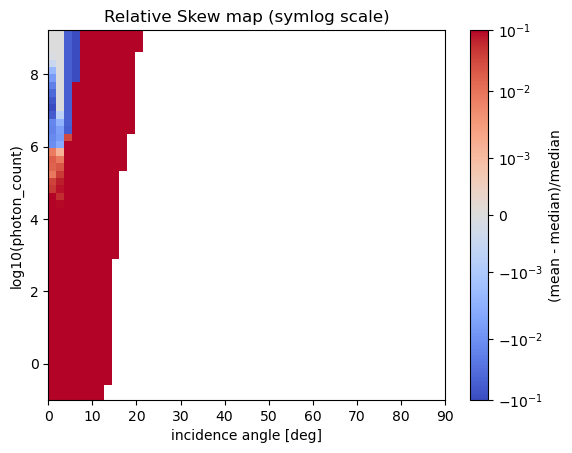

In [5]:
# Check Skewness
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED

linthresh = np.min(skew[np.where(skew > 0)])
vmax = np.nanmax(np.abs(skew))

norm = SymLogNorm(linthresh=linthresh, linscale=1.0,
                  vmin=-vmax, vmax=vmax, base=10)

extent = [COMMON_INC[0], COMMON_INC[-1],
          COMMON_LOG_PC[0], COMMON_LOG_PC[-1]]

plt.imshow(skew, norm=norm, cmap="coolwarm", origin="lower",
           extent=extent, aspect="auto")
plt.ylabel("log10(photon_count)")
plt.xlabel("incidence angle [deg]")
plt.colorbar(label="(mean - median)/median")
plt.title("Relative Skew map (symlog scale)")
plt.show()


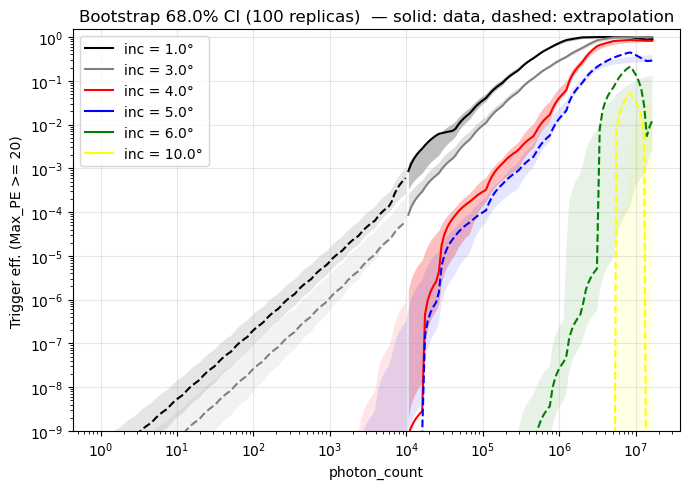

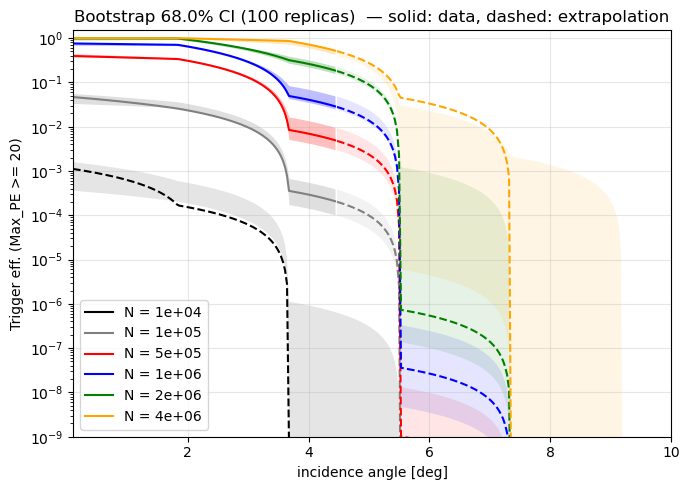

In [6]:
# ---------- Example: efficiency vs photon_count at a few incidences ----------
fig, ax = plt.subplots(figsize=(7, 5))
N_grid = np.logspace(np.log10(pc_.min()),
                     np.log10(pc_.max()) , 200)
log_N_grid = np.log10(N_grid)

for inc_val, color in zip([1, 3, 4, 5, 6, 10], ['black', 'gray', 'red', 'blue', 'green', 'yellow']):
    eff_c, lo, hi = trigger_eff_ci(N_grid, inc_val)

    # Mask: True where we are inside the empirical data coverage box
    inside = (
        (log_N_grid >= np.log10(min(pc_[hit_>0]))) & (log_N_grid <= _DATA_LOG_PC_HI) &
        (inc_val   >= _DATA_INC_LO)    & (inc_val   <= _DATA_INC_HI)
    )

    # Solid segment (inside)
    eff_in = np.where(inside, eff_c, np.nan)
    ax.plot(N_grid, eff_in, color=color, linestyle='-',
            label=f"inc = {inc_val:.1f}°")

    # Dashed segment (extrapolation)
    eff_out = np.where(~inside, eff_c, np.nan)
    ax.plot(N_grid, eff_out, color=color, linestyle='--')

    # CI band everywhere (lighter alpha outside)
    ax.fill_between(N_grid, lo, hi, where=inside,
                    color=color, alpha=0.25, linewidth=0)
    ax.fill_between(N_grid, lo, hi, where=~inside,
                    color=color, alpha=0.10, linewidth=0)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlabel("photon_count")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)  "
             f"— solid: data, dashed: extrapolation")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
# ---------- Example: efficiency vs incidence angle at a few photon counts ----------
fig, ax = plt.subplots(figsize=(7, 5))
inc_grid = np.linspace(inc_.min(), 10.0, 300)

N_values = [1e4, 1e5, 5e5, 1e6, 2e6, 4e6]
colors   = ['black', 'gray', 'red', 'blue', 'green', 'orange']

log_pc_lo = np.log10(min(pc_[hit_ > 0]))

for N_val, color in zip(N_values, colors):
    eff_c, lo, hi = trigger_eff_ci(N_val, inc_grid)

    # Mask: True where we are inside the empirical data coverage box
    inside = (
        (np.log10(N_val) >= log_pc_lo) & (np.log10(N_val) <= _DATA_LOG_PC_HI) &
        (inc_grid        >= _DATA_INC_LO) & (inc_grid     <= _DATA_INC_HI)
    )

    # Solid segment (inside)
    eff_in = np.where(inside, eff_c, np.nan)
    ax.plot(inc_grid, eff_in, color=color, linestyle='-',
            label=f"N = {N_val:.0e}")

    # Dashed segment (extrapolation, including inc > data range up to 10°)
    eff_out = np.where(~inside, eff_c, np.nan)
    ax.plot(inc_grid, eff_out, color=color, linestyle='--')

    # CI band
    ax.fill_between(inc_grid, lo, hi, where=inside,
                    color=color, alpha=0.25, linewidth=0)
    ax.fill_between(inc_grid, lo, hi, where=~inside,
                    color=color, alpha=0.10, linewidth=0)

ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlim(inc_.min(), 10.0)
ax.set_xlabel("incidence angle [deg]")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)  "
             f"— solid: data, dashed: extrapolation")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


In [7]:
# Empirical efficiency cube on (zenith, H, E) — PARALLEL version
# =============================================================================
import os
import numpy as np
from functools import lru_cache
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# ---------- Config ----------
BOOT_SEED   = 123
N_BOOT_EFF  = 50 #no use
MIN_PTS_EFF = 2
N_E_BINS    = 10
N_H_BINS    = 20
N_Z_BINS    = 30
N_AZ_BINS   = 20
N_JOBS      = os.cpu_count()

ENERGY_MIN = 1e1
ENERGY_MAX = 5e5
ZEN_MIN = 80 #np.nanmin(Zenith)
ZEN_MAX = np.nanmax(Zenith)
AZIMUTH_RANGE = 10.0
H_MIN = 5000
H_MAX = 50000

OBS_HEIGHT_M   = 2944.0
EARTH_RADIUS_M = 6_371_000.0

N_PARAMS = 1
PARAM_ORDER = ["dummy"]
COV_FULL = np.zeros((N_PARAMS, N_PARAMS))

# =============================================================================
# Helpers
# =============================================================================

def eff_vs_zenith_with_ci(pc, zenith_deg_arr, psi_deg, phi_max_deg, n_phi,
                          paired=False):
    """
    Per-shower (median, lo, hi) efficiency averaged over phi, for each zenith.

    Returns
    -------
    eff_out, lo_out, hi_out : each a list (len = n_zen) of arrays shape (Nsh,)
    """
    pc = np.asarray(pc, dtype=float)
    zenith_deg_arr = np.atleast_1d(zenith_deg_arr).astype(float)
    n_zen = len(zenith_deg_arr)

    psi = np.deg2rad(psi_deg)
    phi_max = np.deg2rad(phi_max_deg)
    phi = np.linspace(0, phi_max, n_phi)

    if paired:
        if len(pc) != n_zen:
            raise ValueError("paired=True requires len(pc) == len(zenith_deg_arr)")

    eff_out, lo_out, hi_out = [], [], []

    for k in range(n_zen):
        theta_z = np.deg2rad(zenith_deg_arr[k])
        showers = np.array([pc[k]]) if paired else pc          # (Nsh,)

        # incidence angle grid: (Nsh, n_phi)
        cos_theta = (np.cos(psi) * np.cos(theta_z)
                     + np.sin(psi) * np.sin(theta_z) * np.cos(phi))
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        inc_deg = np.broadcast_to(np.degrees(np.arccos(cos_theta)),
                                  (len(showers), n_phi))
        N_b = np.broadcast_to(showers[:, None], (len(showers), n_phi))

        med, lo, hi = trigger_eff_ci(N_b, inc_deg)             # (Nsh, n_phi)

        # average over phi
        denom = phi[-1] - phi[0]
        eff_out.append(np.trapezoid(med, phi, axis=-1) / denom)
        lo_out.append( np.trapezoid(lo,  phi, axis=-1) / denom)
        hi_out.append( np.trapezoid(hi,  phi, axis=-1) / denom)

    return eff_out, lo_out, hi_out

def _process_bin_slant(k, j, i, pc, zen, psi_deg, phi_max_deg, n_phi,
                       reduce, n_boot, seed):
    """Single (zen, H, E) bin for slant extrapolation."""
    reducer = np.mean if reduce == 'mean' else np.median

    eff_vals, lo_vals, hi_vals = eff_vs_zenith_with_ci(
        pc, np.array([zen], dtype=float), psi_deg, phi_max_deg, n_phi, paired=False
    )
    eff_vals = eff_vals[0]
    lo_vals  = lo_vals[0]
    hi_vals  = hi_vals[0]
    if len(eff_vals) == 0:
        return k, j, i, np.nan, np.nan, np.nan
    return (k, j, i,
            reducer(eff_vals),
            reducer(lo_vals),
            reducer(hi_vals))

# =============================================================================
# 3. Empirical efficiency cube  (parallel over (H, E) bins)
# =============================================================================
def _process_bin_HE(k, j, i, zen_deg, pc_sel, psi_deg, phi_max_deg, n_phi):
    if len(pc_sel) == 0:
        return k, j, i, np.nan, np.nan, np.nan
    theta_z = np.radians(zen_deg)
    psi = np.radians(psi_deg)
    phi = np.linspace(0.0, np.radians(phi_max_deg), n_phi)

    cos_t = (np.cos(psi)*np.cos(theta_z)
             + np.sin(psi)*np.sin(theta_z)*np.cos(phi))
    cos_t = np.clip(cos_t, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_t))           # (n_phi,)

    npts = len(pc_sel)
    pc_b  = pc_sel[:, None]                            # (Nsh, 1)
    inc_b = np.broadcast_to(theta_inc, (npts, n_phi))  # (Nsh, n_phi)
    med, lo, hi = trigger_eff_ci(pc_b, inc_b)          # (Nsh, n_phi)

    denom = phi[-1] - phi[0]
    med_phi = np.trapezoid(med, phi, axis=-1) / denom
    lo_phi  = np.trapezoid(lo,  phi, axis=-1) / denom
    hi_phi  = np.trapezoid(hi,  phi, axis=-1) / denom
    return k, j, i, np.mean(med_phi), np.mean(lo_phi), np.mean(hi_phi)

def efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid,
    Energy_GeV, H, photon_count,
    psi_deg=90.0, phi_max_deg=3.0, n_phi=50,
    min_pts=5, reduce='mean',
    n_boot=200, rng=None, n_jobs=1,
):
    n_zen = len(Zen_grid)
    n_H   = len(H_edges) - 1
    n_E   = len(E_edges) - 1
    E_cen = np.sqrt(E_edges[:-1] * E_edges[1:])
    H_cen = 0.5 * (H_edges[:-1] + H_edges[1:])

    EFF     = np.full((n_zen, n_H, n_E), np.nan)
    EFF_LO  = np.full((n_zen, n_H, n_E), np.nan)
    EFF_HI  = np.full((n_zen, n_H, n_E), np.nan)
    COUNTS  = np.zeros((n_zen, n_H, n_E), dtype=int)
    GRAD    = np.zeros((n_zen, n_H, n_E, N_PARAMS))
    pc_in_bin = [[[None]*n_E for _ in range(n_H)] for _ in range(n_zen)]

    # Build tasks
    tasks = []
    for k, zen_deg in enumerate(Zen_grid):
        for i in range(n_E):
            in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i+1])
            for j in range(n_H):
                sel = in_E & (H >= H_edges[j]) & (H < H_edges[j+1])
                npts = int(np.sum(sel))
                COUNTS[k, j, i] = npts
                if npts < min_pts:
                    continue
                pc_sel = photon_count[sel]
                pc_in_bin[k][j][i] = pc_sel
                tasks.append((k, j, i, zen_deg, pc_sel))

    if not tasks:
        return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)

    print(f"efficiency_grid_H_E: {len(tasks)} bins on {n_jobs} CPUs")
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_bin_HE)(k, j, i, zen_deg, pc_sel,
                                 psi_deg, phi_max_deg, n_phi)
        for (k, j, i, zen_deg, pc_sel) in tasks
    )

    for k, j, i, eff_v, lo_v, hi_v in results:
        EFF[k, j, i]    = eff_v
        EFF_LO[k, j, i] = lo_v
        EFF_HI[k, j, i] = hi_v

    return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)

# =============================================================================
# 4. Build (E, Slant) photon-count lookup
# =============================================================================
def build_E_slant_pc_table(E_edges, H_emit, Energy_GeV, photon_count,
                           Zenith_deg, n_slant_bins):
    E_edges = np.asarray(E_edges, dtype=float)
    H_emit = np.asarray(H_emit, dtype=float)
    Energy_GeV = np.asarray(Energy_GeV, dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)
    Zenith_rad = np.radians(np.asarray(Zenith_deg, dtype=float))

    Slant_km = slant_depth(
        H_emit + EARTH_RADIUS_M,
        OBS_HEIGHT_M + EARTH_RADIUS_M,
        Zenith_rad,
    ) / 1000.0

    S_edges = np.linspace(np.nanmin(Slant_km), np.nanmax(Slant_km), n_slant_bins + 1)
    S_cen = 0.5 * (S_edges[:-1] + S_edges[1:])

    n_E = len(E_edges) - 1
    pc_ES = [[None] * n_slant_bins for _ in range(n_E)]
    for i in range(n_E):
        in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i + 1])
        for s in range(n_slant_bins):
            mask = in_E & (Slant_km >= S_edges[s]) & (Slant_km < S_edges[s + 1])
            pc = photon_count[mask]
            pc_ES[i][s] = pc[np.isfinite(pc) & (pc > 0)]
    return S_edges, S_cen, pc_ES

# =============================================================================
# 5. Slant-based extrapolation  (parallel over empty cells)
# =============================================================================
def extrapolate_via_slant(EFF, EFF_LO, EFF_HI,
                          E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                          psi_deg=90.0, phi_max_deg=5.0, n_phi=20,
                          min_pts=5, reduce='mean', n_boot=200,
                          rng=None, n_jobs=N_JOBS):
    if rng is None:
        rng = np.random.default_rng()
    ss = np.random.SeedSequence(rng.integers(0, 2**31 - 1))

    n_zen, n_H, n_E = EFF.shape
    tasks = []
    for k in range(n_zen):
        zen = zenith_deg[k]
        for j in range(n_H):
            slant_km = slant_depth(
                H_cen[j] + EARTH_RADIUS_M,
                OBS_HEIGHT_M + EARTH_RADIUS_M,
                np.deg2rad(zen),
            ) / 1000.0
            si = int(np.clip(np.searchsorted(S_edges, slant_km) - 1,
                             0, len(S_edges) - 2))
            for i in range(n_E):
                if np.isfinite(EFF[k, j, i]):
                    continue
                pc = pc_ES[i][si]
                if pc is None or len(pc) < min_pts:
                    continue
                tasks.append((k, j, i, pc, zen))

    if not tasks:
        return EFF, EFF_LO, EFF_HI

    seeds = [s.generate_state(1)[0] for s in ss.spawn(len(tasks))]
    print(f"extrapolate_via_slant: {len(tasks)} bins on {n_jobs} CPUs")
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_bin_slant)(
            k, j, i, pc, zen, psi_deg, phi_max_deg, n_phi,
            reduce, n_boot, seed)
        for (k, j, i, pc, zen), seed in zip(tasks, seeds)
    )

    for k, j, i, eff_val, lo_val, hi_val in results:
        if np.isfinite(eff_val):
            EFF[k, j, i]    = eff_val
            EFF_LO[k, j, i] = lo_val
            EFF_HI[k, j, i] = hi_val
    return EFF, EFF_LO, EFF_HI

# =============================================================================
# 6. Build efficiency interpolator (unchanged logic)
# =============================================================================
def build_efficiency_interpolator(EFF, EFF_LO, EFF_HI,
                                  E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                                  psi_deg=90.0, phi_max_deg=5.0, n_phi=20,
                                  min_pts=3, reduce='mean', n_boot=200,
                                  rng=None,
                                  H_extrap_range=(0.0, 120_000.0),
                                  n_H_extra=4,
                                  zen_extrap_range=None,
                                  n_zen_extra=2,
                                  n_jobs=N_JOBS):
    H_cen = np.asarray(H_cen, dtype=float)
    zenith_deg = np.asarray(zenith_deg, dtype=float)

    if n_H_extra > 0:
        H_lo = np.linspace(H_extrap_range[0], H_cen[0],  n_H_extra + 1)[:-1]
        H_hi = np.linspace(H_cen[-1], H_extrap_range[1], n_H_extra + 1)[1:]
        H_cen_ext = np.concatenate([H_lo, H_cen, H_hi])
    else:
        H_cen_ext = H_cen.copy()

    if zen_extrap_range is not None and n_zen_extra > 0:
        Z_lo = np.linspace(zen_extrap_range[0], zenith_deg[0],  n_zen_extra + 1)[:-1]
        Z_hi = np.linspace(zenith_deg[-1], zen_extrap_range[1], n_zen_extra + 1)[1:]
        zen_ext = np.concatenate([Z_lo, zenith_deg, Z_hi])
    else:
        zen_ext = zenith_deg.copy()

    z_off = int(np.searchsorted(zen_ext, zenith_deg[0]))
    h_off = int(np.searchsorted(H_cen_ext, H_cen[0]))
    n_zen_ext = len(zen_ext)
    n_H_ext   = len(H_cen_ext)
    n_E       = EFF.shape[2]

    def _embed(arr_old):
        out = np.full((n_zen_ext, n_H_ext, n_E), np.nan)
        out[z_off:z_off+len(zenith_deg), h_off:h_off+len(H_cen), :] = arr_old
        return out

    EFF    = _embed(EFF)
    EFF_LO = _embed(EFF_LO)
    EFF_HI = _embed(EFF_HI)

    H_cen      = H_cen_ext
    zenith_deg = zen_ext

    EFF_filled    = EFF.copy()
    EFF_LO_filled = EFF_LO.copy()
    EFF_HI_filled = EFF_HI.copy()
    fill_mask = ~np.isfinite(EFF)

    nan_mask = ~np.isfinite(EFF_filled)
    if np.any(nan_mask):
        _, idx = distance_transform_edt(nan_mask, return_indices=True)
        EFF_filled[nan_mask]    = EFF_filled[tuple(idx)][nan_mask]
        EFF_LO_filled[nan_mask] = EFF_LO_filled[tuple(idx)][nan_mask]
        EFF_HI_filled[nan_mask] = EFF_HI_filled[tuple(idx)][nan_mask]

    original_nan = ~np.isfinite(EFF)
    edge_mask = np.zeros_like(EFF_filled, dtype=bool)
    edge_mask[:, :2, :]  = True
    edge_mask[:2, :, :]  = True
    edge_mask[-2:, :, :] = True
    reopen = edge_mask & original_nan
    EFF_filled[reopen]    = np.nan
    EFF_LO_filled[reopen] = np.nan
    EFF_HI_filled[reopen] = np.nan

    EFF_filled, EFF_LO_filled, EFF_HI_filled = extrapolate_via_slant(
        EFF_filled, EFF_LO_filled, EFF_HI_filled,
        E_cen, H_cen, zenith_deg, S_edges, pc_ES,
        psi_deg=psi_deg, phi_max_deg=phi_max_deg, n_phi=n_phi,
        min_pts=min_pts, reduce=reduce, n_boot=n_boot, rng=rng,
        n_jobs=n_jobs,
    )

    remaining = ~np.isfinite(EFF_filled)
    if np.any(remaining):
        _, idx2 = distance_transform_edt(remaining, return_indices=True)
        EFF_filled[remaining]    = EFF_filled[tuple(idx2)][remaining]
        EFF_LO_filled[remaining] = EFF_LO_filled[tuple(idx2)][remaining]
        EFF_HI_filled[remaining] = EFF_HI_filled[tuple(idx2)][remaining]

    EFF_filled[~np.isfinite(EFF_filled)]       = 0.0
    EFF_LO_filled[~np.isfinite(EFF_LO_filled)] = 0.0
    EFF_HI_filled[~np.isfinite(EFF_HI_filled)] = 0.0

    log10_E = np.log10(E_cen)
    rgi_eff = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                      EFF_filled, method='linear',
                                      bounds_error=False, fill_value=None)
    rgi_lo  = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                      EFF_LO_filled, method='linear',
                                      bounds_error=False, fill_value=None)
    rgi_hi  = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                      EFF_HI_filled, method='linear',
                                      bounds_error=False, fill_value=None)
    rgi_mask = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                       fill_mask.astype(float), method='nearest',
                                       bounds_error=False, fill_value=1.0)

    def eff_func(E_GeV, H_m, zenith_deg_q):
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float), np.asarray(H_m, float), np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        return np.clip(rgi_eff(pts), 0.0, 1.0).reshape(E_b.shape)

    def eff_sigma_func(E_GeV, H_m, zenith_deg_q):
        """Returns (median, lo, hi)."""
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float), np.asarray(H_m, float), np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        med = np.clip(rgi_eff(pts), 0.0, 1.0).reshape(E_b.shape)
        lo  = np.clip(rgi_lo(pts),  0.0, 1.0).reshape(E_b.shape)
        hi  = np.clip(rgi_hi(pts),  0.0, 1.0).reshape(E_b.shape)
        return med, lo, hi

    def eff_fill_mask_func(E_GeV, H_m, zenith_deg_q):
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float), np.asarray(H_m, float), np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        return (rgi_mask(pts).reshape(E_b.shape) >= 0.5)

    extra = {
        "EFF_filled": EFF_filled,
        "EFF_LO_filled": EFF_LO_filled,
        "EFF_HI_filled": EFF_HI_filled,
        "fill_mask": fill_mask,
        "H_cen_ext": H_cen, "zen_ext": zenith_deg,
    }
    return eff_func, eff_sigma_func, eff_fill_mask_func, extra

def ffill_along_H(EFF, *extras):
    n_zen, n_H, n_E = EFF.shape
    out = EFF.copy()
    extra_outs = [arr.copy() for arr in extras]
    for k in range(n_zen):
        for i in range(n_E):
            col = out[k, :, i]
            finite = np.isfinite(col)
            if not finite.any():
                continue
            idx = np.where(finite, np.arange(n_H), 0)
            np.maximum.accumulate(idx, out=idx)
            out[k, :, i] = col[idx]
            for arr_out in extra_outs:
                arr_out[k, :, i, ...] = arr_out[k, idx, i, ...]
    if extra_outs:
        return (out, *extra_outs)
    return out

# =============================================================================
# Driver
# =============================================================================
rng = np.random.default_rng(BOOT_SEED)
E_edges = np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), N_E_BINS + 1)
H_edges = np.linspace(H_MIN, H_MAX, N_H_BINS + 1)
Zen_grid = np.linspace(ZEN_MIN, ZEN_MAX, N_Z_BINS)

(EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD) = efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid,
    Energy_GeV, H, photon_count,
    psi_deg=90.0, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reduce='mean',
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)

# Forward-fill along H for EFF, EFF_LO, EFF_HI (and GRAD if you still need it)
EFF, EFF_LO, EFF_HI, GRAD = ffill_along_H(EFF, EFF_LO, EFF_HI, GRAD)

S_edges, S_cen, pc_ES = build_E_slant_pc_table(
    E_edges, H, Energy_GeV, photon_count, Zenith,
    n_slant_bins=N_H_BINS,
)

eff_func, eff_sigma_func, eff_fill_mask_func, eff_extra = build_efficiency_interpolator(
    EFF, EFF_LO, EFF_HI, E_cen, H_cen, Zen_grid, S_edges, pc_ES,
    psi_deg=90.0, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reduce='mean',
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)


efficiency_grid_H_E: 6000 bins on 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    1.2s
[Parallel(n_jobs=56)]: Done 176 tasks      | elapsed:    2.5s
[Parallel(n_jobs=56)]: Done 338 tasks      | elapsed:    4.7s
[Parallel(n_jobs=56)]: Done 536 tasks      | elapsed:    7.3s
[Parallel(n_jobs=56)]: Done 770 tasks      | elapsed:    9.8s
[Parallel(n_jobs=56)]: Done 1040 tasks      | elapsed:   12.8s
[Parallel(n_jobs=56)]: Done 1346 tasks      | elapsed:   16.1s
[Parallel(n_jobs=56)]: Done 1688 tasks      | elapsed:   19.8s
[Parallel(n_jobs=56)]: Done 2066 tasks      | elapsed:   23.4s
[Parallel(n_jobs=56)]: Done 2480 tasks      | elapsed:   27.7s
[Parallel(n_jobs=56)]: Done 2930 tasks      | elapsed:   31.7s
[Parallel(n_jobs=56)]: Done 3416 tasks      | elapsed:   36.1s
[Parallel(n_jobs=56)]: Done 3938 tasks      | elapsed:   40.7s
[Parallel(n_jobs=56)]: Done 4496 tasks      | elapsed:   46.1s
[Parallel(n_jobs=56)]: Done 5090 tasks      | 

extrapolate_via_slant: 840 bins on 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    0.3s
[Parallel(n_jobs=56)]: Done 240 tasks      | elapsed:    1.6s
[Parallel(n_jobs=56)]: Done 564 tasks      | elapsed:    2.6s
[Parallel(n_jobs=56)]: Done 840 out of 840 | elapsed:    3.5s finished


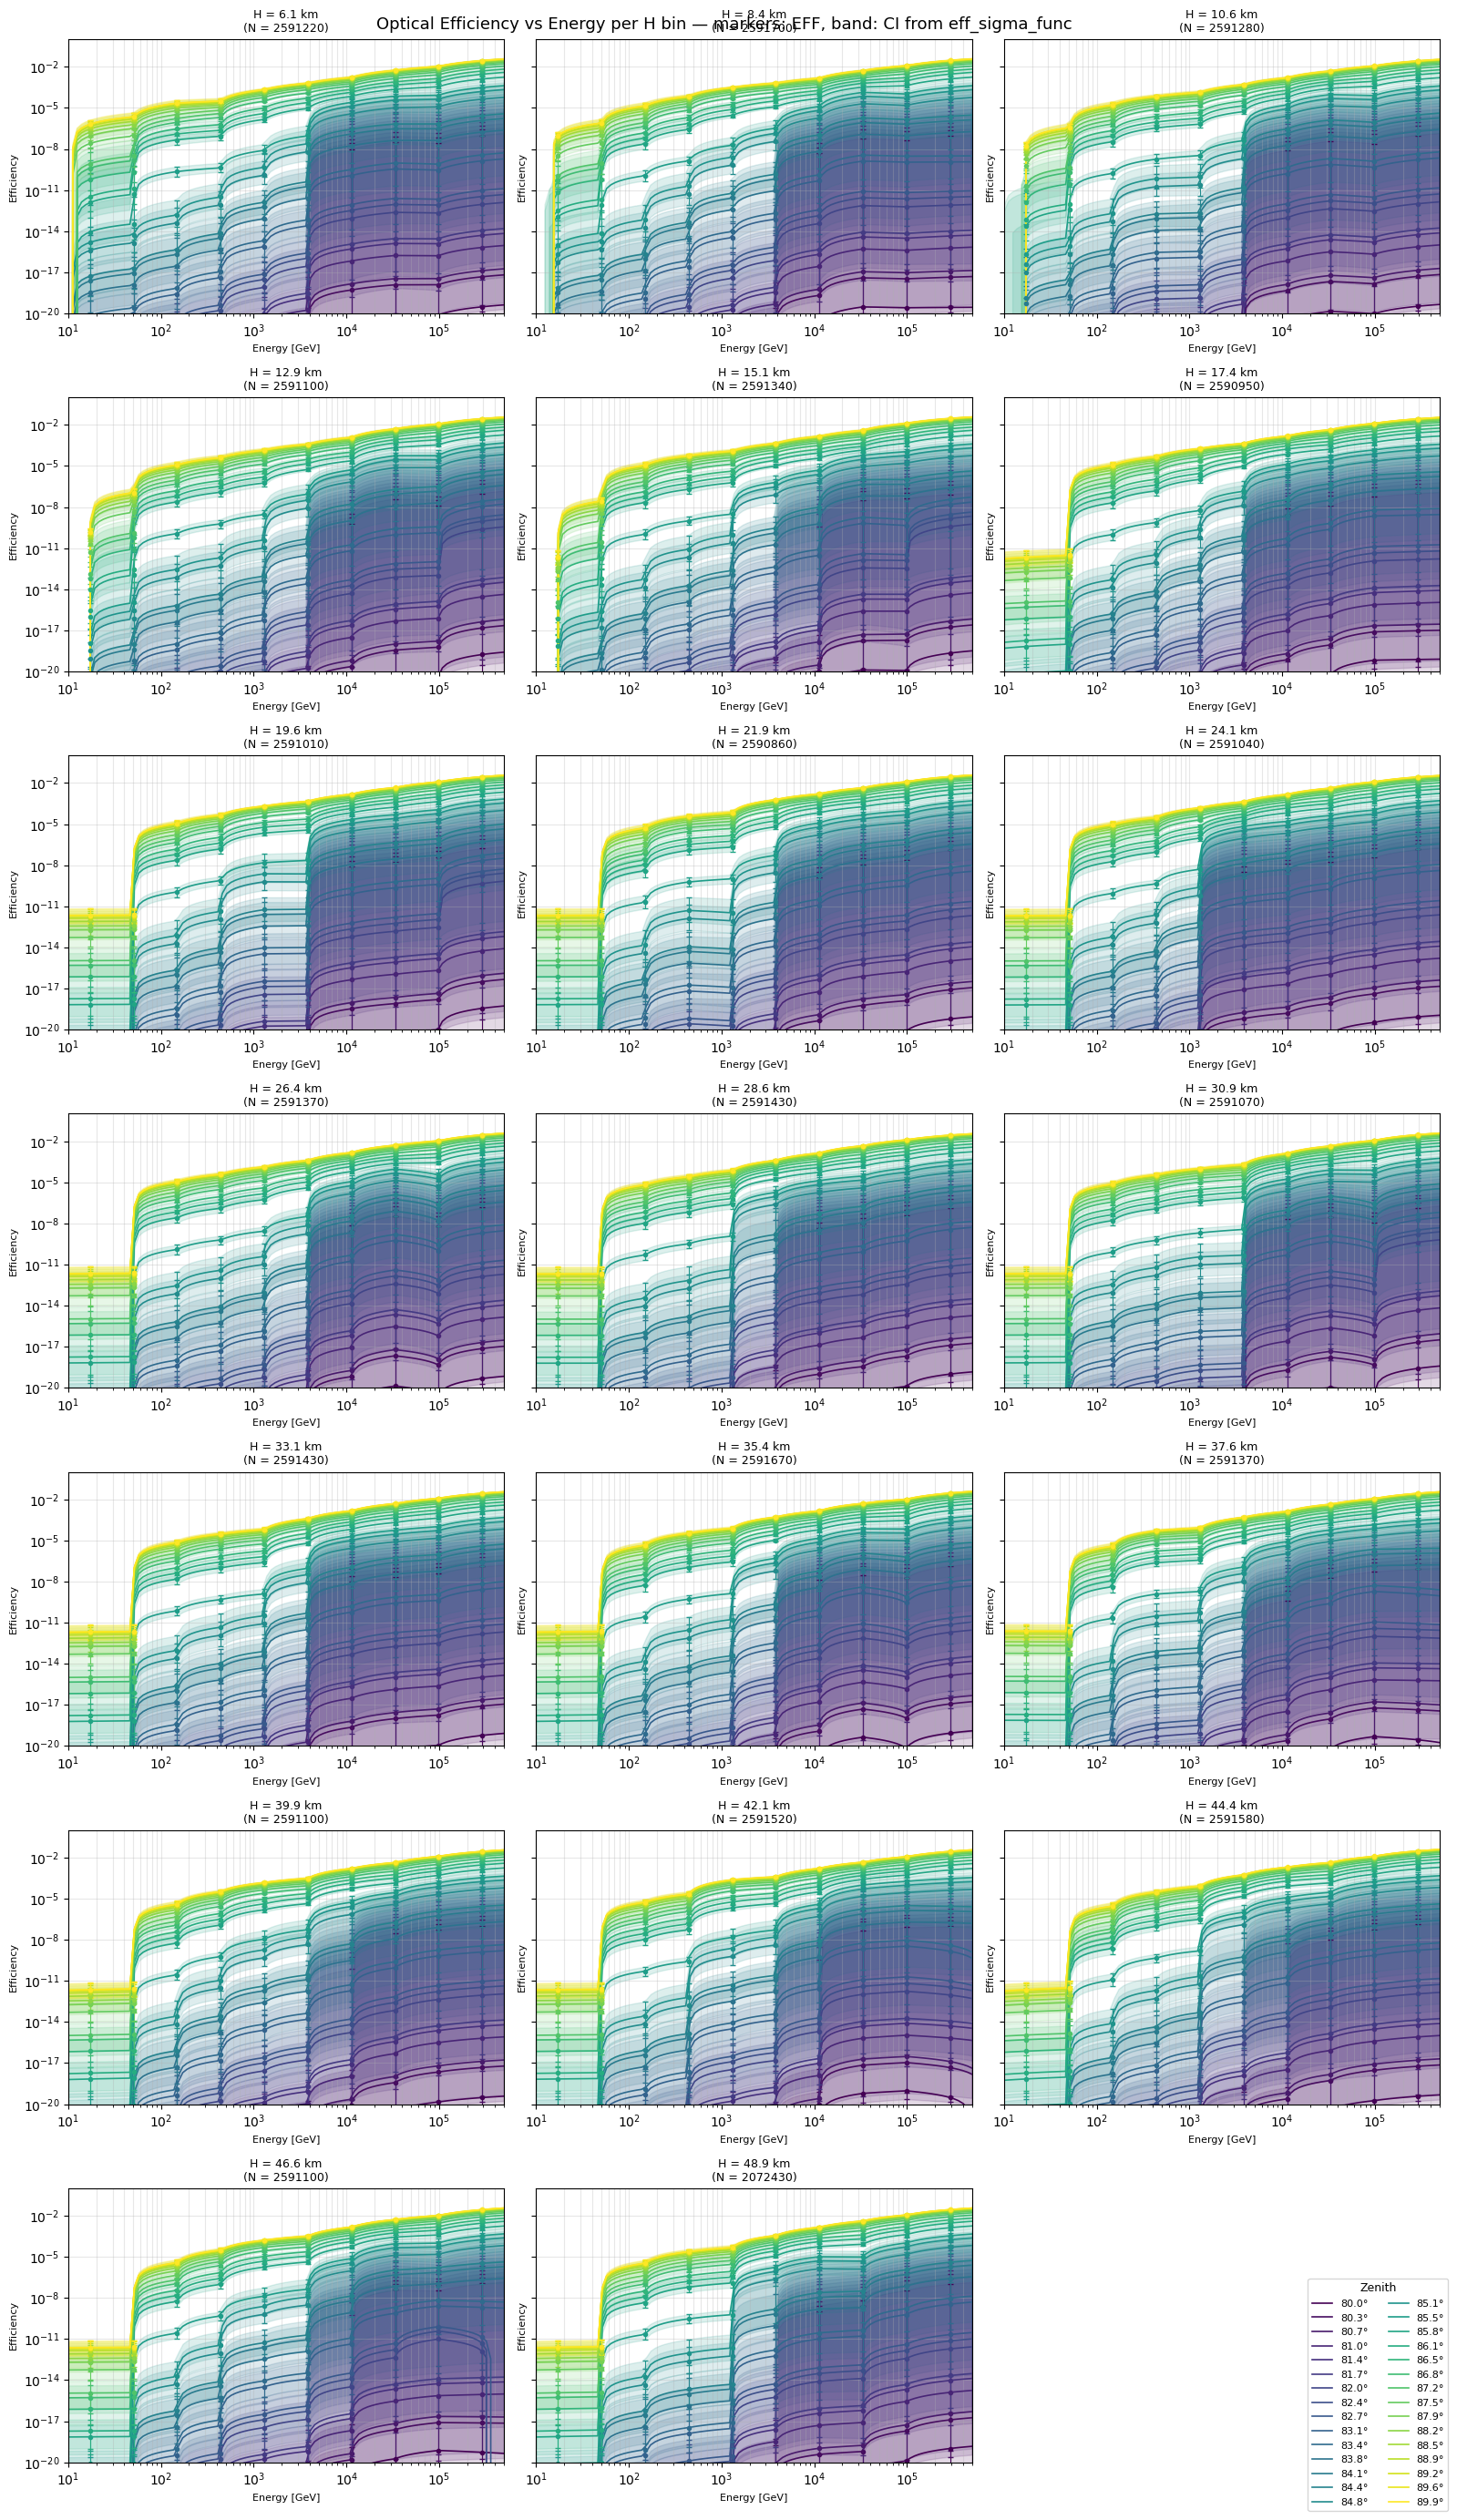

In [52]:
# Testing plot
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

n_H = len(H_cen)
n_Z = len(Zen_grid)

ncols = 3
nrows = int(np.ceil(n_H / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(16, 4 * nrows),
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

colors = cm.viridis(np.linspace(0, 1, n_Z))

E_plot = np.logspace(np.log10(E_edges[0]), np.log10(E_edges[-1]), 100)

for j in range(n_H):
    ax = axes[j]
    H_val = H_cen[j]

    for k, zen in enumerate(Zen_grid):
        # --- interpolator (smooth line + CI band) ---
        med_curve, lo_curve, hi_curve = eff_sigma_func(
            E_plot,
            np.full_like(E_plot, H_val),
            np.full_like(E_plot, zen),
        )

        ax.plot(
            E_plot, med_curve,
            color=colors[k],
            linestyle='-',
            linewidth=1.2,
            label=f"{zen:.1f}°",
        )
        ax.fill_between(E_plot, lo_curve, hi_curve,
                        color=colors[k], alpha=0.15)

        # --- raw EFF with asymmetric error bars (markers) ---
        eff_row = EFF[k, j, :]
        valid = np.isfinite(eff_row)
        if valid.any():
            med_pts, lo_pts, hi_pts = eff_sigma_func(
                E_cen[valid],
                np.full_like(E_cen[valid], H_val),
                np.full_like(E_cen[valid], zen),
            )
            yerr = np.vstack([
                np.clip(eff_row[valid] - lo_pts, 0, None),
                np.clip(hi_pts - eff_row[valid], 0, None),
            ])
            ax.errorbar(
                E_cen[valid], eff_row[valid],
                yerr=yerr,
                color=colors[k],
                marker='o',
                markersize=3,
                linestyle='none',
                elinewidth=0.8,
                capsize=2,
            )

    ax.set_xscale('log')
    ax.set_xlim(E_edges[0], E_edges[-1])
    ax.set_ylim(1e-20, 1)
    ax.set_yscale("log")
    ax.set_title(
        f"H = {H_cen[j]/1e3:.1f} km\n"
        f"(N = {COUNTS[:, j, :].sum()})",
        fontsize=9,
    )
    ax.set_xlabel("Energy [GeV]", fontsize=8)
    ax.set_ylabel("Efficiency",   fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Zenith",
    loc='lower right',
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.0, 0.0),
)

for j in range(n_H, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Optical Efficiency vs Energy per H bin — markers: EFF, band: CI from eff_sigma_func",
             fontsize=13)
plt.tight_layout()
plt.show()


Extending from largest zenith 89.9503° up to 92.0°
Total zenith bins after extension: 120 (range 91.950° → 80.051°)


Slope     m = -3.588042e-03 ± 8.871475e-05
Intercept b = 2.258685e-02 ± 3.836463e-04
Weighted R² = 0.99332
Effective Area (central) = 412328.7528 cm²
Effective Area (MC mean) = 4123943707.01 ± 83079537.16 cm²


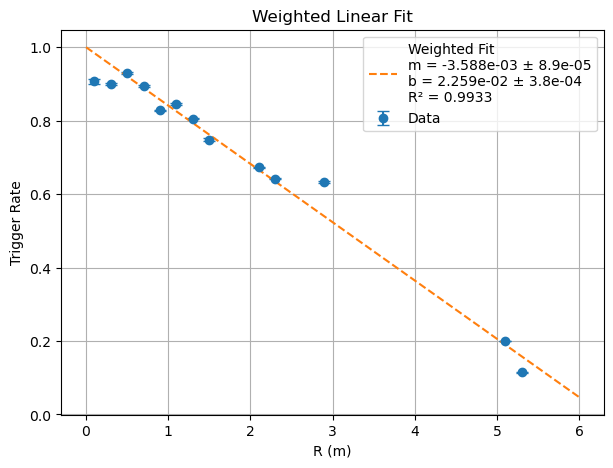

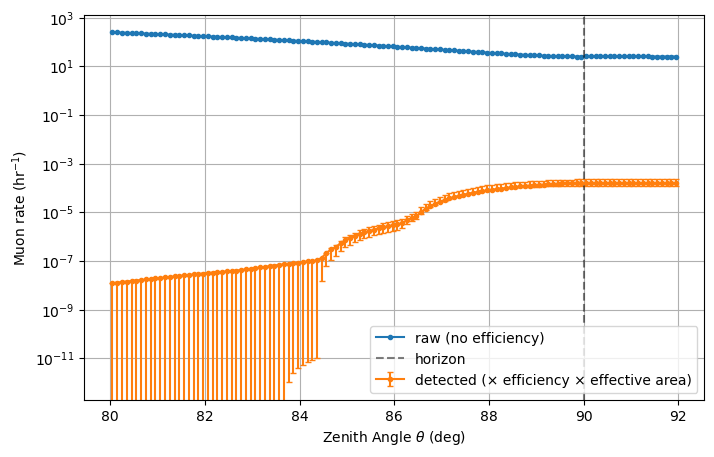


--- Muon Rates per Hour ---
Total (raw, no efficiency):  10673.68641367436
Detected (central):          0.006431443141749297
  ± eff uncertainty (lo/hi): -0.0010753799981418723 / +0.0029949879807351565
  ± area uncertainty:        ±0.00012956561908426478
  ± combined (lo/hi):        -0.001083157140055081 / +0.0029977892278138466

Final: 0.006431443141749297  [0.005348286001694217, 0.009429232369563143]  muons/hour


In [8]:
# Extrapolate to high zenith
import pickle
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 2. Load the precomputed MCEq grid
# =========================================================================
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_80_90deg.pkl', 'rb') as f:
    grid_data = pickle.load(f)

zen_centers_all = grid_data['zen_centers']
cos_edges       = grid_data['cos_edges']
E_GeV           = grid_data['E_GeV']
min_E           = grid_data['min_E']
max_E           = grid_data['max_E']

zen_min_use, zen_max_use = 80, 90.0

zen_mask = (zen_centers_all >= zen_min_use) & (zen_centers_all <= zen_max_use)
if not np.any(zen_mask):
    raise ValueError(
        f"No zenith bins in [{zen_min_use}, {zen_max_use}] deg. "
        f"Available centers: {zen_centers_all}"
    )

zen_centers = zen_centers_all[zen_mask]

tele_azimuth = 270
min_az, max_az = tele_azimuth - AZIMUTH_RANGE, tele_azimuth + AZIMUTH_RANGE
dphi = np.radians(max_az - min_az)
dcos = np.diff(cos_edges)
solid_angles_all = dphi * np.abs(dcos)
solid_angles     = solid_angles_all[zen_mask]

selected_entries = [e for e, keep in zip(grid_data['per_zenith'], zen_mask) if keep]

# =========================================================================
# 2b. EXTEND to 92°
# =========================================================================
extend_to_deg   = 92.0
extra_bin_width = 0.1

idx_max = int(np.argmax(zen_centers))
last_entry = selected_entries[idx_max]
last_theta = last_entry['theta']
print(f"Extending from largest zenith {last_theta:.4f}° up to {extend_to_deg}°")

extra_centers = np.arange(last_theta + extra_bin_width,
                          extend_to_deg + 1e-9,
                          extra_bin_width)

extra_solid_angles = []
for zc in extra_centers:
    c_lo = np.cos(np.radians(zc - extra_bin_width/2))
    c_hi = np.cos(np.radians(zc + extra_bin_width/2))
    extra_solid_angles.append(dphi * abs(c_lo - c_hi))
extra_solid_angles = np.array(extra_solid_angles)

extra_entries = []
for zc in extra_centers:
    extra_entries.append({
        'theta':    zc,
        'd_CDF':    last_entry['d_CDF'],
        'H_grid':   last_entry['H_grid'],
        'sum_mceq': last_entry['sum_mceq'],
    })

zen_centers      = np.concatenate([zen_centers, extra_centers])
solid_angles     = np.concatenate([solid_angles, extra_solid_angles])
selected_entries = selected_entries + extra_entries

order = np.argsort(zen_centers)[::-1]
zen_centers      = zen_centers[order]
solid_angles     = solid_angles[order]
selected_entries = [selected_entries[i] for i in order]

print(f"Total zenith bins after extension: {len(zen_centers)} "
      f"(range {zen_centers[0]:.3f}° → {zen_centers[-1]:.3f}°)")

# =========================================================================
# 3. Loop over zenith and apply efficiency via eff_func / eff_sigma_func
# =========================================================================
Total_flux_raw           = []
Total_flux_detected2     = []
Total_flux_detected2_lo  = []
Total_flux_detected2_hi  = []
eff_map     = []
eff_map_lo  = []
eff_map_hi  = []

for i, entry in enumerate(selected_entries):
    theta    = entry['theta']
    d_CDF    = entry['d_CDF']
    H_grid   = entry['H_grid']
    sum_mceq = entry['sum_mceq']
    H_m = H_grid / 100.0
    Solid_angle = solid_angles[i]

    theta_q = min(theta, Zen_grid[-1])

    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh = np.full_like(H_mesh, theta_q)

    eff_HE2 = eff_func(E_mesh, H_mesh, Z_mesh)
    eff_HE2 = np.nan_to_num(eff_HE2, nan=0.0)

    med_HE2, lo_HE2, hi_HE2 = eff_sigma_func(E_mesh, H_mesh, Z_mesh)
    lo_HE2 = np.nan_to_num(lo_HE2, nan=0.0)
    hi_HE2 = np.nan_to_num(hi_HE2, nan=0.0)

    E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)

    CDF = np.cumsum(d_CDF, axis=0)
    CDF_positive = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = CDF[-1] / CDF_positive[-1]

    integrand_HE2 = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E
    d_CDF_det_E   = np.trapezoid(integrand_HE2[:, E_mask], E_GeV[E_mask], axis=1)
    detected_at_ground2 = np.cumsum(d_CDF_det_E, axis=0)[-1]

    integrand_lo = np.clip(d_CDF, 0, None) * lo_HE2 * survival_prob_per_E
    integrand_hi = np.clip(d_CDF, 0, None) * hi_HE2 * survival_prob_per_E
    d_CDF_det_E_lo = np.trapezoid(integrand_lo[:, E_mask], E_GeV[E_mask], axis=1)
    d_CDF_det_E_hi = np.trapezoid(integrand_hi[:, E_mask], E_GeV[E_mask], axis=1)
    detected_lo = np.cumsum(d_CDF_det_E_lo, axis=0)[-1]
    detected_hi = np.cumsum(d_CDF_det_E_hi, axis=0)[-1]

    weights = survival_prob_per_E * np.clip(d_CDF, 0, None)
    weight_sum = weights.sum(axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        eff_vs_E = np.where(
            weight_sum > 0,
            (weights * eff_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        eff_vs_E_lo = np.where(
            weight_sum > 0,
            (weights * lo_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        eff_vs_E_hi = np.where(
            weight_sum > 0,
            (weights * hi_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )

    cos_factor = 1
    Total_flux_raw.append(          sum_mceq            * Solid_angle * cos_factor)
    Total_flux_detected2.append(    detected_at_ground2 * Solid_angle * cos_factor)
    Total_flux_detected2_lo.append( detected_lo         * Solid_angle * cos_factor)
    Total_flux_detected2_hi.append( detected_hi         * Solid_angle * cos_factor)
    eff_map.append(eff_vs_E)
    eff_map_lo.append(eff_vs_E_lo)
    eff_map_hi.append(eff_vs_E_hi)

Total_flux_raw          = np.array(Total_flux_raw)
Total_flux_detected2    = np.array(Total_flux_detected2)
Total_flux_detected2_lo = np.array(Total_flux_detected2_lo)
Total_flux_detected2_hi = np.array(Total_flux_detected2_hi)
eff_map    = np.array(eff_map)
eff_map_lo = np.array(eff_map_lo)
eff_map_hi = np.array(eff_map_hi)

# =========================================================================
# 4. Effective area from digitized trigger-rate data
# =========================================================================

# --- Digitized data ---
R_data = np.array([
    0.10, 0.30, 0.50, 0.70, 0.90,
    1.10, 1.30, 1.50, 2.10, 2.30,
    2.90, 5.10, 5.30
])

trigger_data = np.array([
    0.0205, 0.0203, 0.0210, 0.0202,
    0.0187, 0.0191, 0.0182, 0.0169,
    0.0152, 0.0145, 0.0143,
    0.0045, 0.0026
])

trigger_rate_err = np.array([
    0.0065, 0.0028, 0.0022, 0.0020,
    0.0017, 0.0020, 0.0025, 0.0035,
    0.0013, 0.0020, 0.0032, 0.0005,
    0.0010
])

# --- Weighted linear fit ---
fit_weights = 1.0 / trigger_rate_err**2

(p, cov_fit) = np.polyfit(
    R_data,
    trigger_data,
    deg=1,
    w=np.sqrt(fit_weights),
    cov=True
)

m_fit, b_fit = p
m_err = np.sqrt(cov_fit[0, 0])
b_err = np.sqrt(cov_fit[1, 1])

print(f"Slope     m = {m_fit:.6e} ± {m_err:.6e}")
print(f"Intercept b = {b_fit:.6e} ± {b_err:.6e}")

# --- Weighted R² ---
y_fit        = m_fit * R_data + b_fit
weighted_mean = np.average(trigger_data, weights=fit_weights)
ss_res = np.sum(fit_weights * (trigger_data - y_fit)**2)
ss_tot = np.sum(fit_weights * (trigger_data - weighted_mean)**2)
r_squared = 1 - ss_res / ss_tot
print(f"Weighted R² = {r_squared:.5f}")

# --- Central effective area ---
r_grid = np.linspace(0, 6, 10000)
trigger_rate_r      = np.clip(m_fit * r_grid + b_fit, 0, None)
trigger_rate_r_norm = trigger_rate_r / trigger_rate_r.max()
effective_area_central = 2 * np.pi * np.trapezoid(
    trigger_rate_r_norm * r_grid, x=r_grid
)
print(f"Effective Area (central) = {effective_area_central * 1e4:.4f} cm²")

# --- Monte Carlo uncertainty propagation ---
N_mc = 1000
samples = np.random.multivariate_normal(
    mean=[m_fit, b_fit],
    cov=cov_fit,
    size=N_mc
)

area_samples = []
for m_i, b_i in samples:
    trigger_i = np.clip(m_i * r_grid + b_i, 0, None)
    if trigger_i.max() <= 0:
        continue
    trigger_i_norm = trigger_i / trigger_i.max()
    area_i = 2 * np.pi * np.trapezoid(trigger_i_norm * r_grid, x=r_grid)
    area_samples.append(area_i)

area_samples = np.array(area_samples) * 1e4 #convert to cm^2

effective_area_mean = np.mean(area_samples) 
effective_area_std  = np.std(area_samples) 

print(f"Effective Area (MC mean) = {effective_area_mean * 1e4:.2f} ± "
      f"{effective_area_std * 1e4:.2f} cm²")

# --- Fit plot ---
plt.figure(figsize=(7, 5))
plt.errorbar(R_data, trigger_data/np.max(m_fit * r_grid + b_fit), yerr=trigger_rate_err,
             fmt='o', capsize=4, label='Data')
plt.plot(r_grid, (m_fit * r_grid + b_fit)/np.max(m_fit * r_grid + b_fit), '--',
         label=(f'Weighted Fit\n'
                f'm = {m_fit:.3e} ± {m_err:.1e}\n'
                f'b = {b_fit:.3e} ± {b_err:.1e}\n'
                f'R² = {r_squared:.4f}'))
plt.xlabel("R (m)")
plt.ylabel("Trigger Rate")
plt.title("Weighted Linear Fit")
plt.grid(True)
plt.legend()
plt.show()

# =========================================================================
# 5. Muon rates with combined efficiency + effective-area uncertainties
# =========================================================================

# Summed fluxes (units: cm⁻² s⁻¹ sr⁻¹  ×  sr  →  cm⁻² s⁻¹)
flux_central = np.sum(Total_flux_detected2)
flux_lo      = np.sum(Total_flux_detected2_lo)
flux_hi      = np.sum(Total_flux_detected2_hi)
flux_raw     = np.sum(Total_flux_raw)

# Central rates  (× effective area [cm²] × seconds per hour)
seconds_per_hour = 3600.0
Rate_central = flux_central * effective_area_mean * seconds_per_hour
Rate_raw     = flux_raw     * effective_area_mean * seconds_per_hour

# --- Uncertainty from efficiency (asymmetric) ---
dRate_eff_lo = (flux_central - flux_lo) * effective_area_mean * seconds_per_hour
dRate_eff_hi = (flux_hi - flux_central) * effective_area_mean * seconds_per_hour

# --- Uncertainty from effective area (symmetric, from MC std) ---
dRate_area   = flux_central * effective_area_std * seconds_per_hour

# --- Combined uncertainties (add in quadrature) ---
dRate_total_lo = np.sqrt(dRate_eff_lo**2 + dRate_area**2)
dRate_total_hi = np.sqrt(dRate_eff_hi**2 + dRate_area**2)

# --- Plot muon rate per hour vs zenith ---
seconds_per_hour = 3600.0

# Convert fluxes → muons/hour using effective area (already in cm²)
Rate_raw_zen      = Total_flux_raw       * effective_area_mean * seconds_per_hour
Rate_det_zen      = Total_flux_detected2 * effective_area_mean * seconds_per_hour
Rate_det_zen_lo   = Total_flux_detected2_lo * effective_area_mean * seconds_per_hour
Rate_det_zen_hi   = Total_flux_detected2_hi * effective_area_mean * seconds_per_hour

# Efficiency-driven asymmetric uncertainty
dRate_eff_lo_zen = np.clip(Rate_det_zen - Rate_det_zen_lo, 0, None)
dRate_eff_hi_zen = np.clip(Rate_det_zen_hi - Rate_det_zen, 0, None)

# Effective-area symmetric uncertainty (per-bin)
dRate_area_zen   = Total_flux_detected2 * effective_area_std * seconds_per_hour

# Combined in quadrature
dRate_lo_zen = np.sqrt(dRate_eff_lo_zen**2 + dRate_area_zen**2)
dRate_hi_zen = np.sqrt(dRate_eff_hi_zen**2 + dRate_area_zen**2)

plt.figure(figsize=(8, 5))
plt.plot(zen_centers, Rate_raw_zen, '.-', label='raw (no efficiency)')
plt.errorbar(zen_centers, Rate_det_zen,
             yerr=np.vstack([dRate_lo_zen, dRate_hi_zen]),
             fmt='.-', capsize=2,
             label='detected (× efficiency × effective area)')
plt.axvline(90, color='k', ls='--', alpha=0.5, label='horizon')
plt.xlabel(r'Zenith Angle $\theta$ (deg)')
plt.ylabel(r'Muon rate (hr$^{-1}$)')
plt.yscale('log')
plt.legend(); plt.grid(); plt.show()


print("\n--- Muon Rates per Hour ---")
print(f"Total (raw, no efficiency):  {Rate_raw}")
print(f"Detected (central):          {Rate_central}")
print(f"  ± eff uncertainty (lo/hi): -{dRate_eff_lo} / +{dRate_eff_hi}")
print(f"  ± area uncertainty:        ±{dRate_area}")
print(f"  ± combined (lo/hi):        -{dRate_total_lo} / +{dRate_total_hi}")
print(f"\nFinal: {Rate_central}  [{Rate_central-dRate_total_lo}, {Rate_central+dRate_total_hi}]  muons/hour")


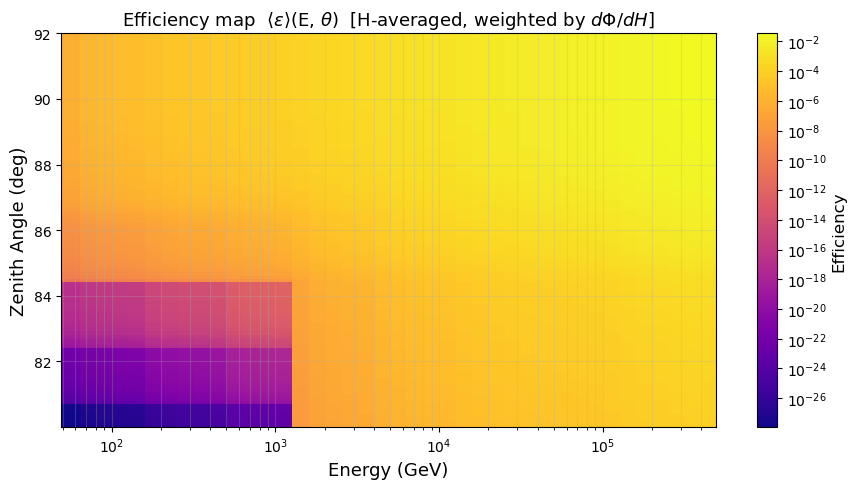

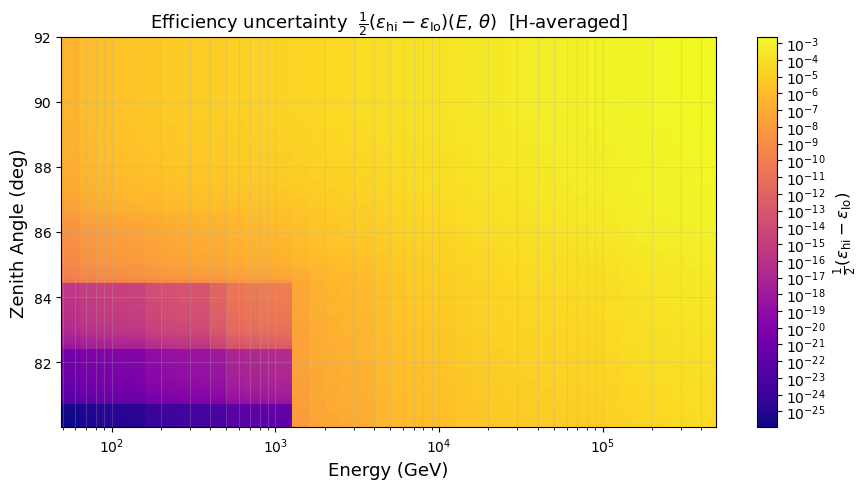

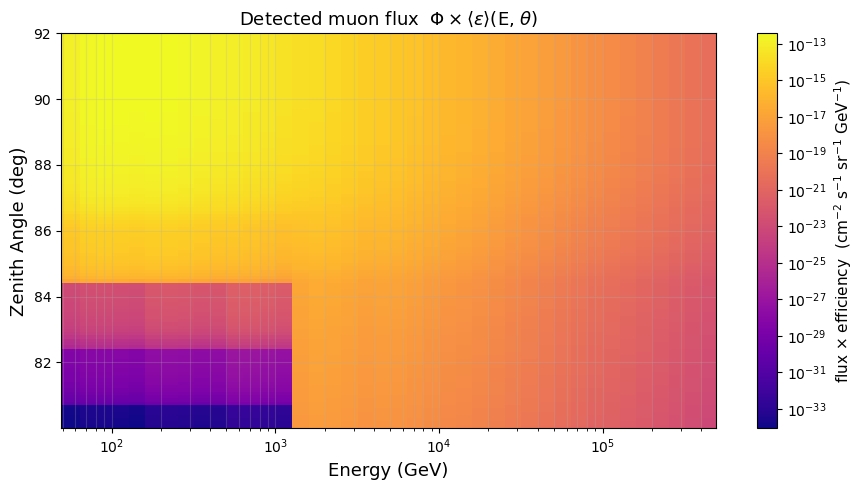

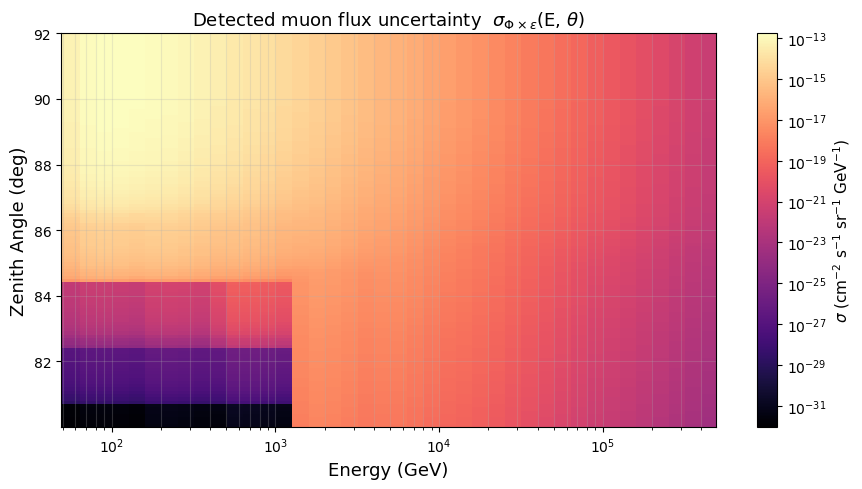

In [9]:
from matplotlib.colors import SymLogNorm

E_mask_plot = (E_GeV > 5e1) & (E_GeV < 5e5)

# =========================================================================
# Build flux_raw_map from selected_entries (shape: n_zen x n_E)
# Each entry['d_CDF'] has shape (n_H, n_E); sum over H axis to get per-E flux
# =========================================================================
flux_raw_map = np.full((len(selected_entries), len(E_GeV)), np.nan)
for i, entry in enumerate(selected_entries):
    d = entry['d_CDF']
    # d_CDF may be (n_H, n_E) or (n_E,) depending on MCEq grid structure
    flux_raw_map[i, :] = d.sum(axis=0) if d.ndim == 2 else d

# =========================================================================
# Efficiency asymmetric half-widths  (n_zen, n_E)
# =========================================================================
eff_map_err_lo = np.clip(eff_map - eff_map_lo, 0, None)   # downward uncertainty
eff_map_err_hi = np.clip(eff_map_hi - eff_map, 0, None)   # upward uncertainty
eff_map_err    = 0.5 * (eff_map_err_lo + eff_map_err_hi)  # symmetric mid-point for plotting

# Muon flux × efficiency
flux_x_eff_map     = flux_raw_map * eff_map      # (n_zen, n_E)
flux_x_eff_err_map = flux_raw_map * eff_map_err  # (n_zen, n_E)

# =========================================================================
# Helper to make a SymLogNorm safely
# =========================================================================
def _symlog_norm(data, fallback=1e-12):
    pos = data[np.isfinite(data) & (data > 0)]
    linthresh = pos.min() if pos.size else fallback
    return SymLogNorm(linthresh=linthresh, linscale=0.5, base=10)

# =========================================================================
# Plot 1: Efficiency map
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    eff_map[:, E_mask_plot],
    shading='auto',
    cmap='plasma',
    norm=_symlog_norm(eff_map[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency map  $\langle\varepsilon\rangle$(E, $\theta$)'
             r'  [H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label('Efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# Plot 2: Efficiency uncertainty map  (symmetric half-width of CI)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    eff_map_err[:, E_mask_plot],
    shading='auto',
    cmap='plasma',
    norm=_symlog_norm(eff_map_err[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty  '
             r'$\frac{1}{2}(\varepsilon_\mathrm{hi} - \varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$  [H-averaged]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label(
    r'$\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# Plot 3: Muon flux × efficiency map
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    flux_x_eff_map[:, E_mask_plot],
    shading='auto',
    cmap='plasma',
    norm=_symlog_norm(flux_x_eff_map[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(
    r'Detected muon flux  $\Phi \times \langle\varepsilon\rangle$(E, $\theta$)',
    fontsize=13)
fig.colorbar(pcm, ax=ax).set_label(
    r'flux $\times$ efficiency  (cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$)',
    fontsize=11)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# Plot 4: Detected muon flux uncertainty map
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    flux_x_eff_err_map[:, E_mask_plot],
    shading='auto',
    cmap='magma',
    norm=_symlog_norm(flux_x_eff_err_map[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Detected muon flux uncertainty  '
             r'$\sigma_{\Phi\times\varepsilon}$(E, $\theta$)', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label(
    r'$\sigma$ (cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$)', fontsize=11)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()


In [10]:
import pickle

E_save_mask = (E_GeV >= 5e1) & (E_GeV <= 5e5)

eff_map_output = {
    'zen_centers':   zen_centers,
    'E_GeV':         E_GeV[E_save_mask],
    'H_grid':        selected_entries[0]['H_grid'],
    'eff_map':       eff_map[:, E_save_mask],
    'eff_map_lo':    eff_map_lo[:, E_save_mask],
    'eff_map_hi':    eff_map_hi[:, E_save_mask],
    'eff_map_err':   eff_map_err[:, E_save_mask],   # symmetric half-width
    'min_E':         1e2,
    'max_E':         5e5,
    'zen_range':     (zen_min_use, zen_max_use),
    'extend_to_deg': extend_to_deg,
}

out_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(eff_map_output, f)

print(f"Saved eff_map to {out_path}")
print(f"  E range:           {E_GeV[E_save_mask].min():.1e} – {E_GeV[E_save_mask].max():.1e} GeV  ({E_save_mask.sum()} bins)")
print(f"  eff_map shape:     {eff_map[:, E_save_mask].shape}")
print(f"  eff_map_lo shape:  {eff_map_lo[:, E_save_mask].shape}")
print(f"  eff_map_hi shape:  {eff_map_hi[:, E_save_mask].shape}")
print(f"  eff_map_err shape: {eff_map_err[:, E_save_mask].shape}")


Saved eff_map to /uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl
  E range:           5.6e+01 – 4.5e+05 GeV  (40 bins)
  eff_map shape:     (120, 40)
  eff_map_lo shape:  (120, 40)
  eff_map_hi shape:  (120, 40)
  eff_map_err shape: (120, 40)


Zenith bins: 120  (91.95° → 80.05°)
Energy bins: 40  (5.62e+01 → 4.47e+05 GeV)
eff_map shape:     (120, 40)
eff_map_lo shape:  (120, 40)
eff_map_hi shape:  (120, 40)
eff_map_err shape: (120, 40)


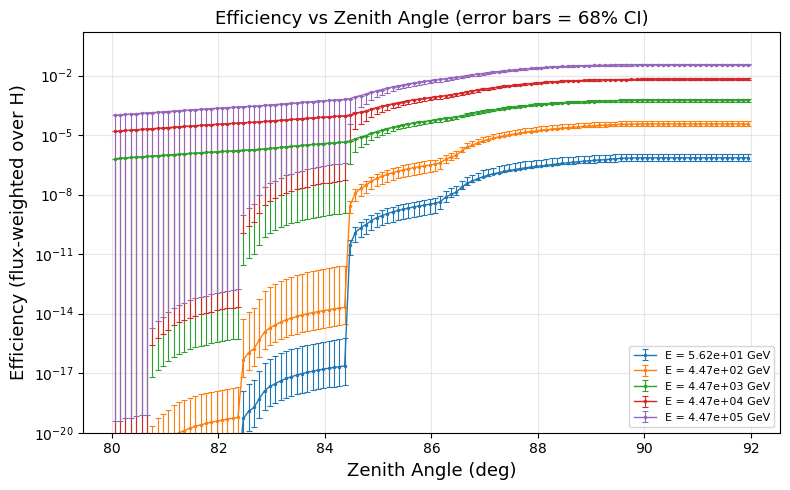

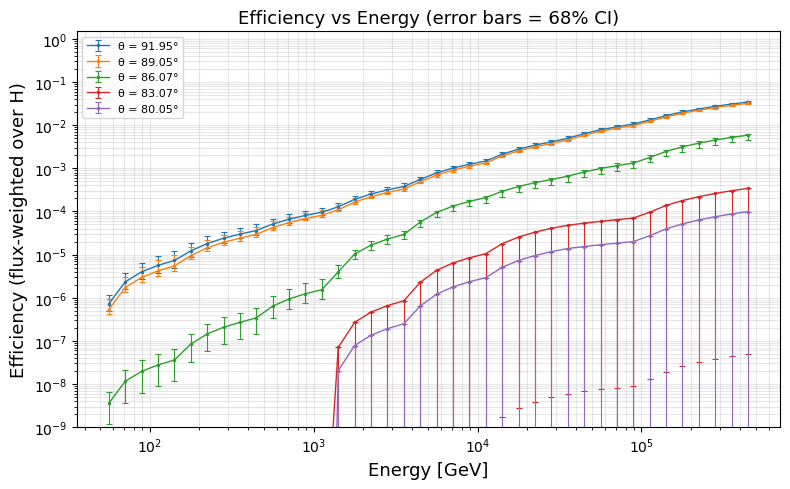

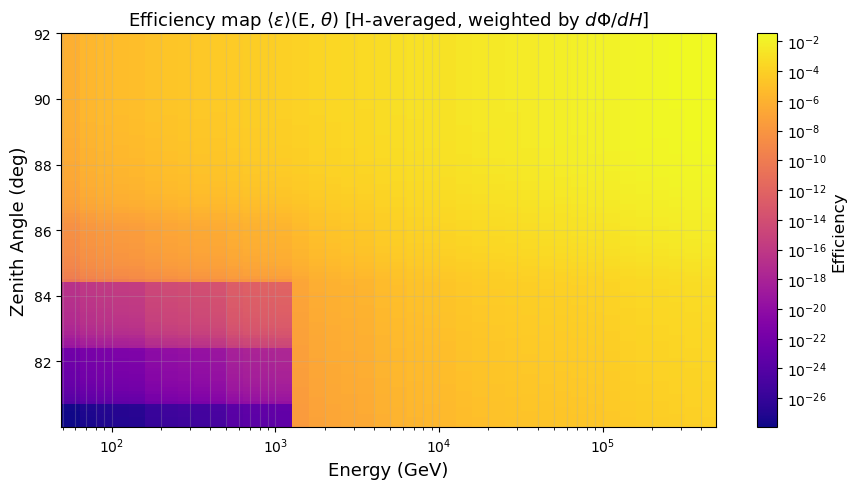

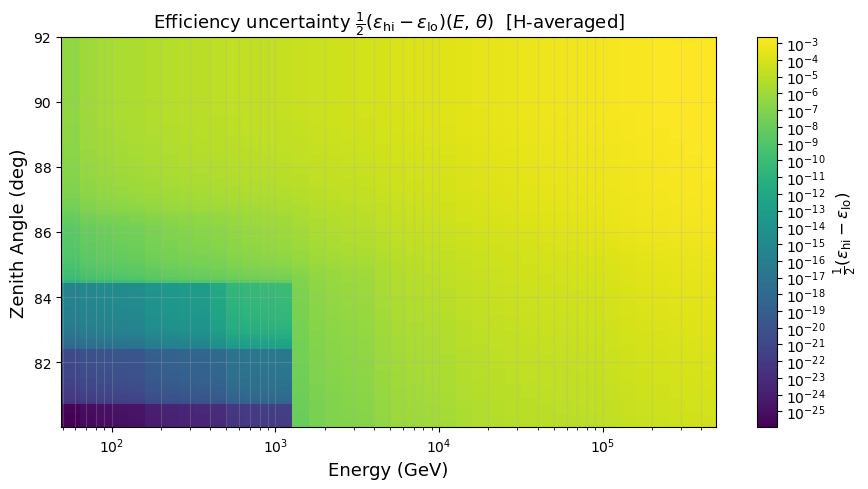

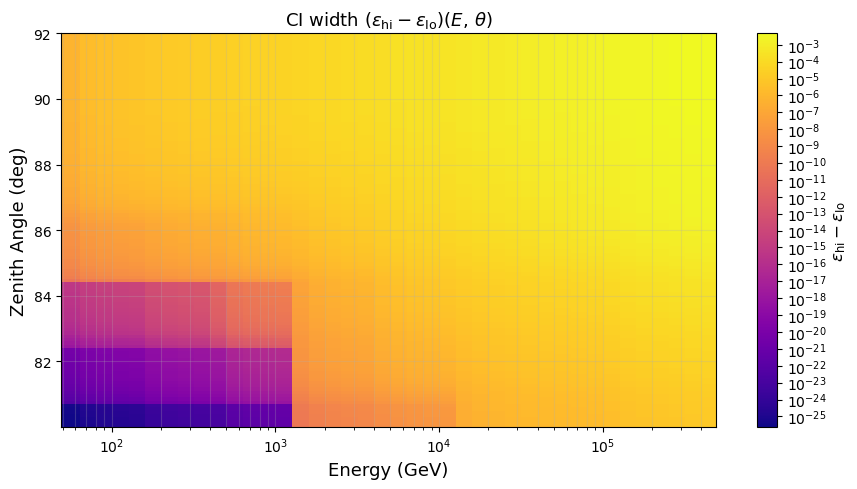

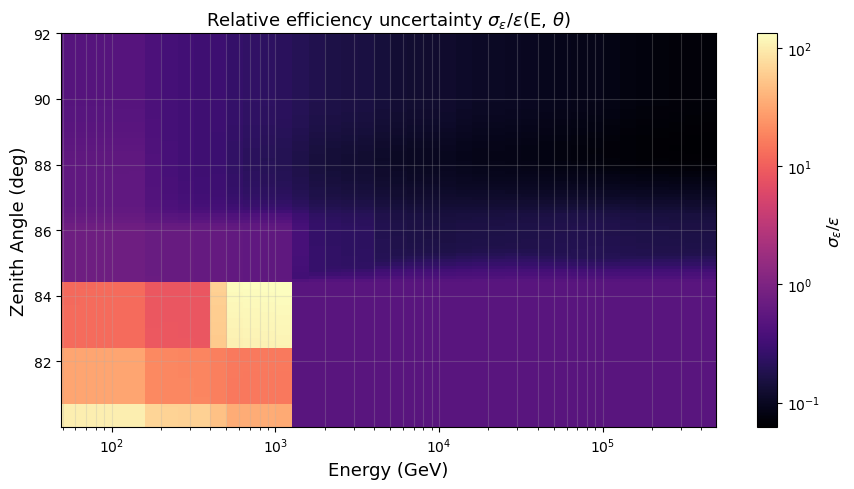

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

in_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'

with open(in_path, 'rb') as f:
    data = pickle.load(f)

zen_centers = data['zen_centers']
E_GeV       = data['E_GeV']
eff_map     = data['eff_map']
eff_map_lo  = data['eff_map_lo']
eff_map_hi  = data['eff_map_hi']
eff_map_err = data['eff_map_err']   # symmetric half-width

# Asymmetric half-widths for error bars
err_lo = np.clip(eff_map - eff_map_lo, 0, None)  # downward
err_hi = np.clip(eff_map_hi - eff_map, 0, None)  # upward

print(f"Zenith bins: {len(zen_centers)}  ({zen_centers[0]:.2f}° → {zen_centers[-1]:.2f}°)")
print(f"Energy bins: {len(E_GeV)}  ({E_GeV[0]:.2e} → {E_GeV[-1]:.2e} GeV)")
print(f"eff_map shape:     {eff_map.shape}")
print(f"eff_map_lo shape:  {eff_map_lo.shape}")
print(f"eff_map_hi shape:  {eff_map_hi.shape}")
print(f"eff_map_err shape: {eff_map_err.shape}")

def _symlog_norm(data, fallback=1e-12):
    pos = data[np.isfinite(data) & (data > 0)]
    linthresh = pos.min() if pos.size else fallback
    return SymLogNorm(linthresh=linthresh, linscale=0.5, base=10)
# =========================================================================
# 1a. Efficiency vs Zenith (line plot with asymmetric error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Pick a few energy bins to display (e.g., 5 evenly spaced across the array)
n_show_E = min(5, len(E_GeV))
idxs_E = np.linspace(0, len(E_GeV) - 1, n_show_E, dtype=int)

for j in idxs_E:
    # eff_map has shape (N_zenith, N_energy), so we slice [:, j] to get all zenith bins for energy j
    ax.errorbar(
        zen_centers, eff_map[:, j],
        yerr=[err_lo[:, j], err_hi[:, j]],          # asymmetric CI
        label=f"E = {E_GeV[j]:.2e} GeV",
        marker='.', markersize=3, linewidth=1,
        capsize=2, capthick=0.8, elinewidth=0.8,
    )

ax.set_yscale('log')
ax.set_ylim(1e-20, 1.5)
ax.set_xlabel('Zenith Angle (deg)', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Zenith Angle (error bars = 68% CI)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 1b. Efficiency vs Energy (line plot with asymmetric error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))
n_show = min(5, len(zen_centers))
idxs = np.linspace(0, len(zen_centers) - 1, n_show, dtype=int)
for i in idxs:
    ax.errorbar(
        E_GeV, eff_map[i],
        yerr=[err_lo[i], err_hi[i]],          # asymmetric CI
        label=f"θ = {zen_centers[i]:.2f}°",
        marker='.', markersize=3, linewidth=1,
        capsize=2, capthick=0.8, elinewidth=0.8,
    )
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlabel('Energy [GeV]', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Energy (error bars = 68% CI)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 2. Efficiency 2D heatmap
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV, zen_centers, eff_map,
    shading='auto', cmap='plasma',
    norm=_symlog_norm(eff_map),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency map $\langle\varepsilon\rangle$(E, $\theta$) '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label('Efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 3a. Efficiency uncertainty 2D heatmap  (symmetric half-width)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm_err = ax.pcolormesh(
    E_GeV, zen_centers, eff_map_err,
    shading='auto', cmap='viridis',
    norm=_symlog_norm(eff_map_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty $\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$  [H-averaged]', fontsize=13)
fig.colorbar(pcm_err, ax=ax).set_label(
    r'$\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 3b. Asymmetric CI width: hi - lo
# =========================================================================
ci_width = np.clip(eff_map_hi - eff_map_lo, 0, None)
fig, ax = plt.subplots(figsize=(9, 5))
pcm_ci = ax.pcolormesh(
    E_GeV, zen_centers, ci_width,
    shading='auto', cmap='plasma',
    norm=_symlog_norm(ci_width),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'CI width $(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$', fontsize=13)
fig.colorbar(pcm_ci, ax=ax).set_label(
    r'$\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo}$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 4. Relative uncertainty 2D heatmap  (sigma / eff)
# =========================================================================
rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
pcm_rel = ax.pcolormesh(
    E_GeV, zen_centers, rel_err,
    shading='auto', cmap='magma',
    norm=_symlog_norm(rel_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Relative efficiency uncertainty $\sigma_\varepsilon / \varepsilon$(E, $\theta$)',
             fontsize=13)
fig.colorbar(pcm_rel, ax=ax).set_label(
    r'$\sigma_\varepsilon / \varepsilon$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()
